---
title: Coalescent with Selection
---


- [Kimura (1962)](https://doi.org/10.1093/genetics/47.6.713) - Fixation probability under selection
- [Kaplan et al. (1988)](https://doi.org/10.1093/genetics/120.3.819) - Coalescent with selection
- [Røikjer et al. (2022)](https://doi.org/10.1007/s11222-022-10155-6) - Phase-type distribution algorithms

In [1]:
from phasic import Graph, StateIndexer, Property, with_ipv

import numpy as np
from scipy.stats import binom, betabinom, beta
from scipy.special import comb
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from tqdm.auto import tqdm

from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')

Each lineage in our coalescent is characterized by two properties:
- **is_derived**: Whether the lineage carries the derived (selected) allele
- **n_descendants**: Number of sampled descendants of this lineage

The state space tracks how many lineages exist of each type. For a sample of size $n$, we need to track lineages with 1 to $n-1$ descendants (a lineage with $n$ descendants is the MRCA and represents absorption).



# Wright-Fisher with Selection: Enhanced Beta-Binomial Approximation

## Extending the Binned State Space Approach to Non-Neutral Evolution

This notebook extends the Beta-Binomial approximation from the neutral Wright-Fisher model to include **natural selection**. The key challenge is that selection introduces a nonlinear transformation of allele frequencies that must be properly accounted for.

### References
- [Kimura (1962)](https://doi.org/10.1093/genetics/47.6.713) - Fixation probability under selection
- [Ewens (2004)](https://link.springer.com/book/10.1007/978-0-387-21822-9) - Mathematical Population Genetics

In [2]:
import numpy as np
from scipy.stats import binom, betabinom, beta
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Optional
import warnings
from tqdm.auto import tqdm, trange
from vscodenb import set_vscode_theme

set_vscode_theme()
sns.set_palette('tab10')
# Set style
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['font.size'] = 12

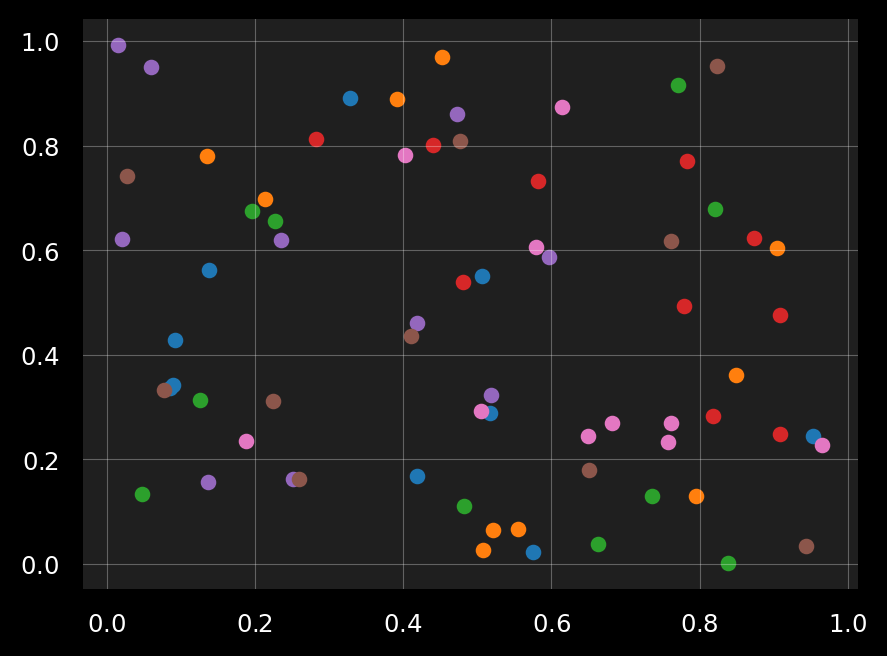

In [3]:
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.scatter(np.random.random(10), np.random.random(10))
plt.show()

# Part 1: Mathematical Foundation

## 1.1 Wright-Fisher with Selection

### The Selection Model

In the Wright-Fisher model with selection, allele A has fitness $w_A = 1 + s$ and allele a has fitness $w_a = 1$, where $s$ is the **selection coefficient**:
- $s > 0$: Allele A is beneficial (positive selection)
- $s < 0$: Allele A is deleterious (negative selection)  
- $s = 0$: Neutral evolution

### Effective Frequency

After selection but before drift, the **effective frequency** is:

$$\tilde{p} = \frac{p \cdot w_A}{p \cdot w_A + (1-p) \cdot w_a} = \frac{p(1+s)}{1 + sp}$$

This accounts for the differential reproductive success of the two alleles.

### Full Transition

The transition probability from state $i$ to state $j$ becomes:

$$P(i \to j) = \binom{N}{j} \tilde{p}_i^j (1-\tilde{p}_i)^{N-j}$$

where $\tilde{p}_i = \frac{(i/N)(1+s)}{1 + s(i/N)}$

## 1.2 The Problem with Naive Beta-Binomial

### Why Can't We Just Transform the Mean?

In the neutral case, if frequency $p$ is distributed according to $\text{Beta}(\alpha, \beta)$ within a bin, we use:
- Mean: $\mu_p = \alpha/(\alpha+\beta)$
- Then sample from $\text{Beta-Binomial}(N, \alpha, \beta)$

With selection, we might naively try:
1. Transform the mean: $\tilde{\mu} = \mu_p(1+s)/(1+s\mu_p)$
2. Use this in a Beta-Binomial

**This is wrong** because the transformation $g(p) = p(1+s)/(1+sp)$ is **nonlinear**!

By **Jensen's inequality**:
$$E[g(p)] \neq g(E[p])$$

### The Correct Approach

We must:
1. Compute the actual distribution of $\tilde{p} = g(p)$ when $p \sim \text{Beta}(\alpha, \beta)$
2. Fit a new $\text{Beta}(\tilde{\alpha}, \tilde{\beta})$ to this transformed distribution
3. Use $\text{Beta-Binomial}(N, \tilde{\alpha}, \tilde{\beta})$ for transitions

## 1.3 Moment Transformation: The Delta Method

### Taylor Expansion Approach

For a nonlinear transformation $g(p)$, we can approximate the moments using Taylor expansion around $\mu_p = E[p]$:

**Mean of transformed variable:**
$$E[g(p)] \approx g(\mu_p) + \frac{1}{2}g''(\mu_p)\sigma_p^2$$

**Variance of transformed variable:**
$$\text{Var}(g(p)) \approx [g'(\mu_p)]^2 \sigma_p^2$$

### Derivatives of the Selection Transform

For $g(p) = \frac{p(1+s)}{1+sp}$:

$$g'(p) = \frac{1+s}{(1+sp)^2}$$

$$g''(p) = \frac{-2s(1+s)}{(1+sp)^3}$$

### Effect of Selection on the Mean

Notice that $g''(p) < 0$ when $s > 0$. This means:

$$E[\tilde{p}] < g(\mu_p) = \frac{\mu_p(1+s)}{1+s\mu_p}$$

The variance in the starting frequency **reduces** the expected benefit from selection! This is a form of **genetic load** - variation decreases the effectiveness of selection.

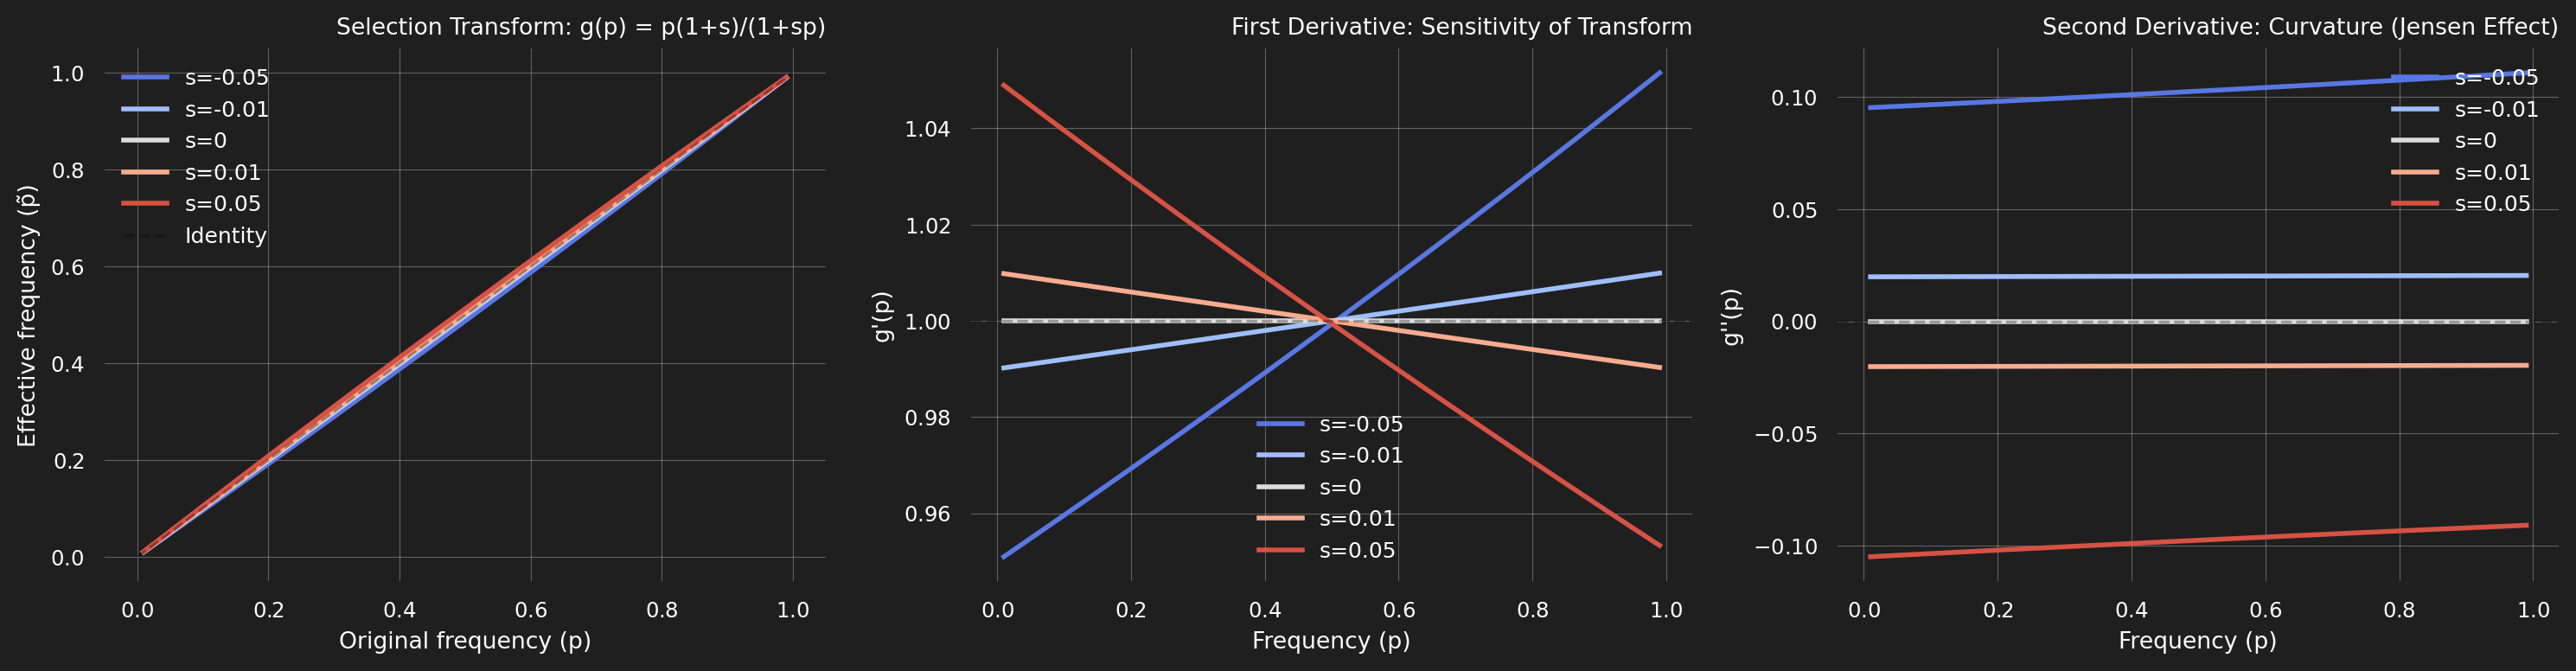

In [4]:
# Core transformation functions

def selection_transform(p, s):
    """Transform frequency under selection: p_tilde = p(1+s)/(1+sp)"""
    p = np.asarray(p)
    if s == 0:
        return p
    return p * (1 + s) / (1 + s * p)

def selection_transform_derivative(p, s):
    """First derivative: g'(p) = (1+s)/(1+sp)^2"""
    if s == 0:
        return 1.0
    return (1 + s) / (1 + s * p) ** 2

def selection_transform_second_derivative(p, s):
    """Second derivative: g''(p) = -2s(1+s)/(1+sp)^3"""
    if s == 0:
        return 0.0
    return -2 * s * (1 + s) / (1 + s * p) ** 3

# Visualize the transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

p_range = np.linspace(0.01, 0.99, 100)
selection_values = [-0.05, -0.01, 0, 0.01, 0.05]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(selection_values)))

# Plot 1: Transform function
for s, c in zip(selection_values, colors):
    axes[0].plot(p_range, selection_transform(p_range, s), color=c, 
                 linewidth=2, label=f's={s}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Identity')
axes[0].set_xlabel('Original frequency (p)')
axes[0].set_ylabel('Effective frequency (p̃)')
axes[0].set_title('Selection Transform: g(p) = p(1+s)/(1+sp)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: First derivative
for s, c in zip(selection_values, colors):
    axes[1].plot(p_range, [selection_transform_derivative(p, s) for p in p_range], 
                 color=c, linewidth=2, label=f's={s}')
axes[1].axhline(1, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Frequency (p)')
axes[1].set_ylabel("g'(p)")
axes[1].set_title('First Derivative: Sensitivity of Transform')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3: Second derivative (curvature)
for s, c in zip(selection_values, colors):
    axes[2].plot(p_range, [selection_transform_second_derivative(p, s) for p in p_range], 
                 color=c, linewidth=2, label=f's={s}')
axes[2].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Frequency (p)')
axes[2].set_ylabel("g''(p)")
axes[2].set_title('Second Derivative: Curvature (Jensen Effect)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.4 Computing Transformed Beta Parameters

### Delta Method Approximation

Given $p \sim \text{Beta}(\alpha, \beta)$ with:
- $\mu_p = \frac{\alpha}{\alpha+\beta}$
- $\sigma_p^2 = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

The transformed moments are approximately:

$$\tilde{\mu} = g(\mu_p) + \frac{1}{2}g''(\mu_p)\sigma_p^2$$

$$\tilde{\sigma}^2 = [g'(\mu_p)]^2 \sigma_p^2$$

### Fitting New Beta Parameters

From method of moments for $\text{Beta}(\tilde{\alpha}, \tilde{\beta})$:

$$\tilde{s} = \frac{\tilde{\mu}(1-\tilde{\mu})}{\tilde{\sigma}^2} - 1$$

$$\tilde{\alpha} = \tilde{\mu} \cdot \tilde{s}, \quad \tilde{\beta} = (1-\tilde{\mu}) \cdot \tilde{s}$$

In [5]:
def transformed_beta_moments_delta(alpha, beta_param, s):
    """
    Compute mean and variance of transformed frequency using delta method.
    
    If p ~ Beta(alpha, beta), compute E[g(p)] and Var(g(p))
    where g(p) = p(1+s)/(1+sp) using Taylor expansion.
    """
    # Original Beta moments
    mu_p = alpha / (alpha + beta_param)
    var_p = (alpha * beta_param) / ((alpha + beta_param)**2 * (alpha + beta_param + 1))
    
    if s == 0:
        return mu_p, var_p
    
    # Transform using delta method
    g_mu = selection_transform(mu_p, s)
    g_prime = selection_transform_derivative(mu_p, s)
    g_double_prime = selection_transform_second_derivative(mu_p, s)
    
    mean_tilde = g_mu + 0.5 * g_double_prime * var_p
    var_tilde = g_prime**2 * var_p
    
    return float(mean_tilde), float(var_tilde)


def transformed_beta_moments_exact(alpha, beta_param, s):
    """
    Compute exact mean and variance via numerical integration.
    
    E[g(p)] = integral_0^1 g(p) * Beta_pdf(p) dp
    """
    if s == 0:
        mu_p = alpha / (alpha + beta_param)
        var_p = (alpha * beta_param) / ((alpha + beta_param)**2 * (alpha + beta_param + 1))
        return mu_p, var_p
    
    beta_dist = beta(alpha, beta_param)
    
    def integrand_mean(p):
        return selection_transform(p, s) * beta_dist.pdf(p)
    
    def integrand_sq(p):
        return selection_transform(p, s)**2 * beta_dist.pdf(p)
    
    mean_tilde, _ = quad(integrand_mean, 0, 1, limit=100)
    mean_sq_tilde, _ = quad(integrand_sq, 0, 1, limit=100)
    var_tilde = mean_sq_tilde - mean_tilde**2
    
    return float(mean_tilde), float(max(0, var_tilde))


# Compare delta method vs exact integration
print("Comparison: Delta Method vs Exact Integration")
print("="*60)
print(f"{'α':>6} {'β':>6} {'s':>8} {'μ_delta':>12} {'μ_exact':>12} {'error':>10}")
print("-"*60)

test_cases = [
    (5, 5, 0.01),   # Symmetric, weak selection
    (5, 5, 0.05),   # Symmetric, moderate selection
    (2, 8, 0.01),   # Asymmetric, weak
    (2, 8, 0.05),   # Asymmetric, moderate
    (10, 2, -0.02), # Deleterious
]

for alpha, beta_param, s in test_cases:
    mu_delta, var_delta = transformed_beta_moments_delta(alpha, beta_param, s)
    mu_exact, var_exact = transformed_beta_moments_exact(alpha, beta_param, s)
    error = abs(mu_delta - mu_exact)
    print(f"{alpha:>6} {beta_param:>6} {s:>8.3f} {mu_delta:>12.6f} {mu_exact:>12.6f} {error:>10.6f}")

Comparison: Delta Method vs Exact Integration
     α      β        s      μ_delta      μ_exact      error
------------------------------------------------------------
     5      5    0.010     0.502261     0.502261   0.000000
     5      5    0.050     0.511087     0.511087   0.000000
     2      8    0.010     0.201451     0.201451   0.000000
     2      8    0.050     0.207180     0.207183   0.000004
    10      2   -0.020     0.830729     0.830728   0.000000


# Part 2: Theoretical Predictions for Validation

## 2.1 Kimura's Fixation Probability

The probability that an allele starting at frequency $p_0$ will eventually fix in the population is given by [Kimura (1962)](https://doi.org/10.1093/genetics/47.6.713):

$$P_{\text{fix}} = \frac{1 - e^{-2Nsp_0}}{1 - e^{-2Ns}}$$

### Special Cases

1. **Neutral** ($s \to 0$): $P_{\text{fix}} = p_0$

2. **Strong positive selection** ($2Ns \gg 1$): $P_{\text{fix}} \approx 1 - e^{-2Nsp_0}$

3. **New beneficial mutation** ($p_0 = 1/N$, $s > 0$): 
   $$P_{\text{fix}} \approx \frac{2s}{1 - e^{-2Ns}} \approx 2s \text{ for small } s$$
   This is **Haldane's approximation** from 1927.

4. **Deleterious mutation** ($s < 0$): $P_{\text{fix}} < p_0$

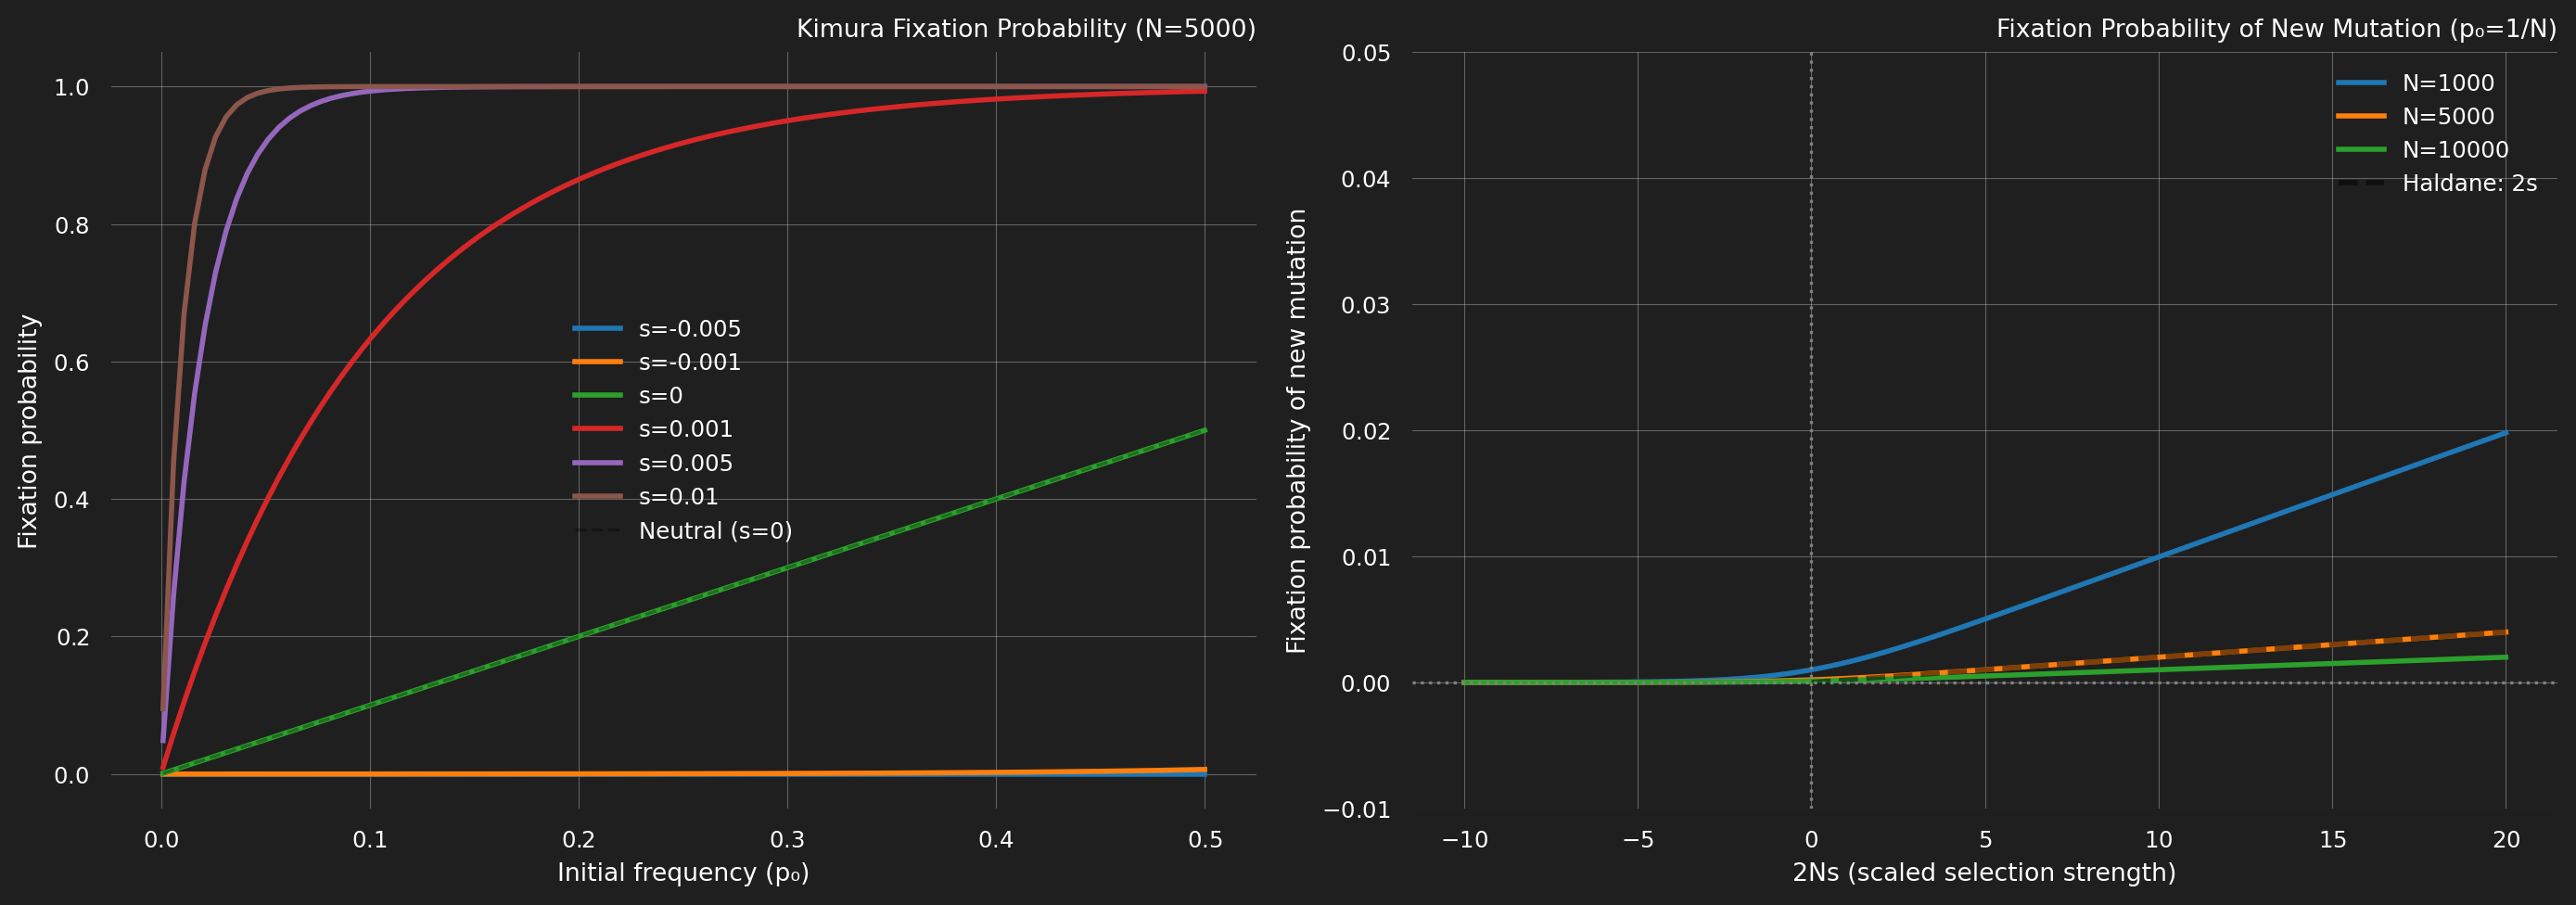

In [6]:
def kimura_fixation_probability(p0, N, s):
    """
    Kimura (1962) fixation probability formula.
    
    P_fix = (1 - exp(-2Ns*p0)) / (1 - exp(-2Ns))
    """
    if s == 0:
        return p0
    
    two_Ns = 2 * N * s
    
    # Numerical stability for small s
    if abs(two_Ns) < 1e-6:
        return p0
    
    numerator = 1 - np.exp(-two_Ns * p0)
    denominator = 1 - np.exp(-two_Ns)
    
    if np.abs(denominator) < 1e-10:
        return p0
    
    return numerator / denominator


# Visualize fixation probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P_fix vs initial frequency for various s
ax = axes[0]
p0_range = np.linspace(0.001, 0.5, 100)
N = 5000

selection_values = [-0.005, -0.001, 0, 0.001, 0.005, 0.01]
#colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(selection_values)))

# for s, c in zip(selection_values, colors):
for s in selection_values:
    p_fix = [kimura_fixation_probability(p0, N, s) for p0 in p0_range]
    # ax.plot(p0_range, p_fix, color=c, linewidth=2, label=f's={s}')
    ax.plot(p0_range, p_fix, linewidth=2, label=f's={s}')

ax.plot(p0_range, p0_range, 'k--', alpha=0.3, label='Neutral (s=0)')
ax.set_xlabel('Initial frequency (p₀)')
ax.set_ylabel('Fixation probability')
ax.set_title(f'Kimura Fixation Probability (N={N})')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: P_fix for new mutation (p0=1/N) vs 2Ns
ax = axes[1]
two_Ns_range = np.linspace(-10, 20, 200)
N_values = [1000, 5000, 10000]

for N in N_values:
    p0 = 1/N
    s_range = two_Ns_range / (2 * N)
    p_fix = [kimura_fixation_probability(p0, N, s) for s in s_range]
    ax.plot(two_Ns_range, p_fix, linewidth=2, label=f'N={N}')

# Add Haldane approximation
two_Ns_pos = np.linspace(0.01, 20, 100)
haldane_approx = 2 * two_Ns_pos / (2 * N_values[0])  # This is just 2s
# But 2s = 2Ns / N, so for fair comparison:
haldane = two_Ns_pos / N_values[1]  # 2s when 2Ns is on x-axis, for N=5000
ax.plot(two_Ns_pos, haldane, 'k--', alpha=0.5, linewidth=2, label='Haldane: 2s')

ax.axhline(0, color='gray', linestyle=':')
ax.axvline(0, color='gray', linestyle=':')
ax.set_xlabel('2Ns (scaled selection strength)')
ax.set_ylabel('Fixation probability of new mutation')
ax.set_title('Fixation Probability of New Mutation (p₀=1/N)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.01, 0.05)

plt.tight_layout()
plt.show()

## 2.2 Expected Frequency Change

The deterministic change in frequency per generation (ignoring drift) is:

$$\Delta p = \tilde{p} - p = \frac{p(1+s)}{1+sp} - p = \frac{sp(1-p)}{1+sp}$$

For weak selection ($s \ll 1$):
$$\Delta p \approx sp(1-p)$$

This is the **logistic selection equation** - the frequency change is proportional to both:
- The selection coefficient $s$
- The heterozygosity $p(1-p)$ (variance in allele frequency)

### Key Insight

Selection is most effective when $p \approx 0.5$ (maximum heterozygosity). At extreme frequencies (near 0 or 1), selection has diminishing effect.

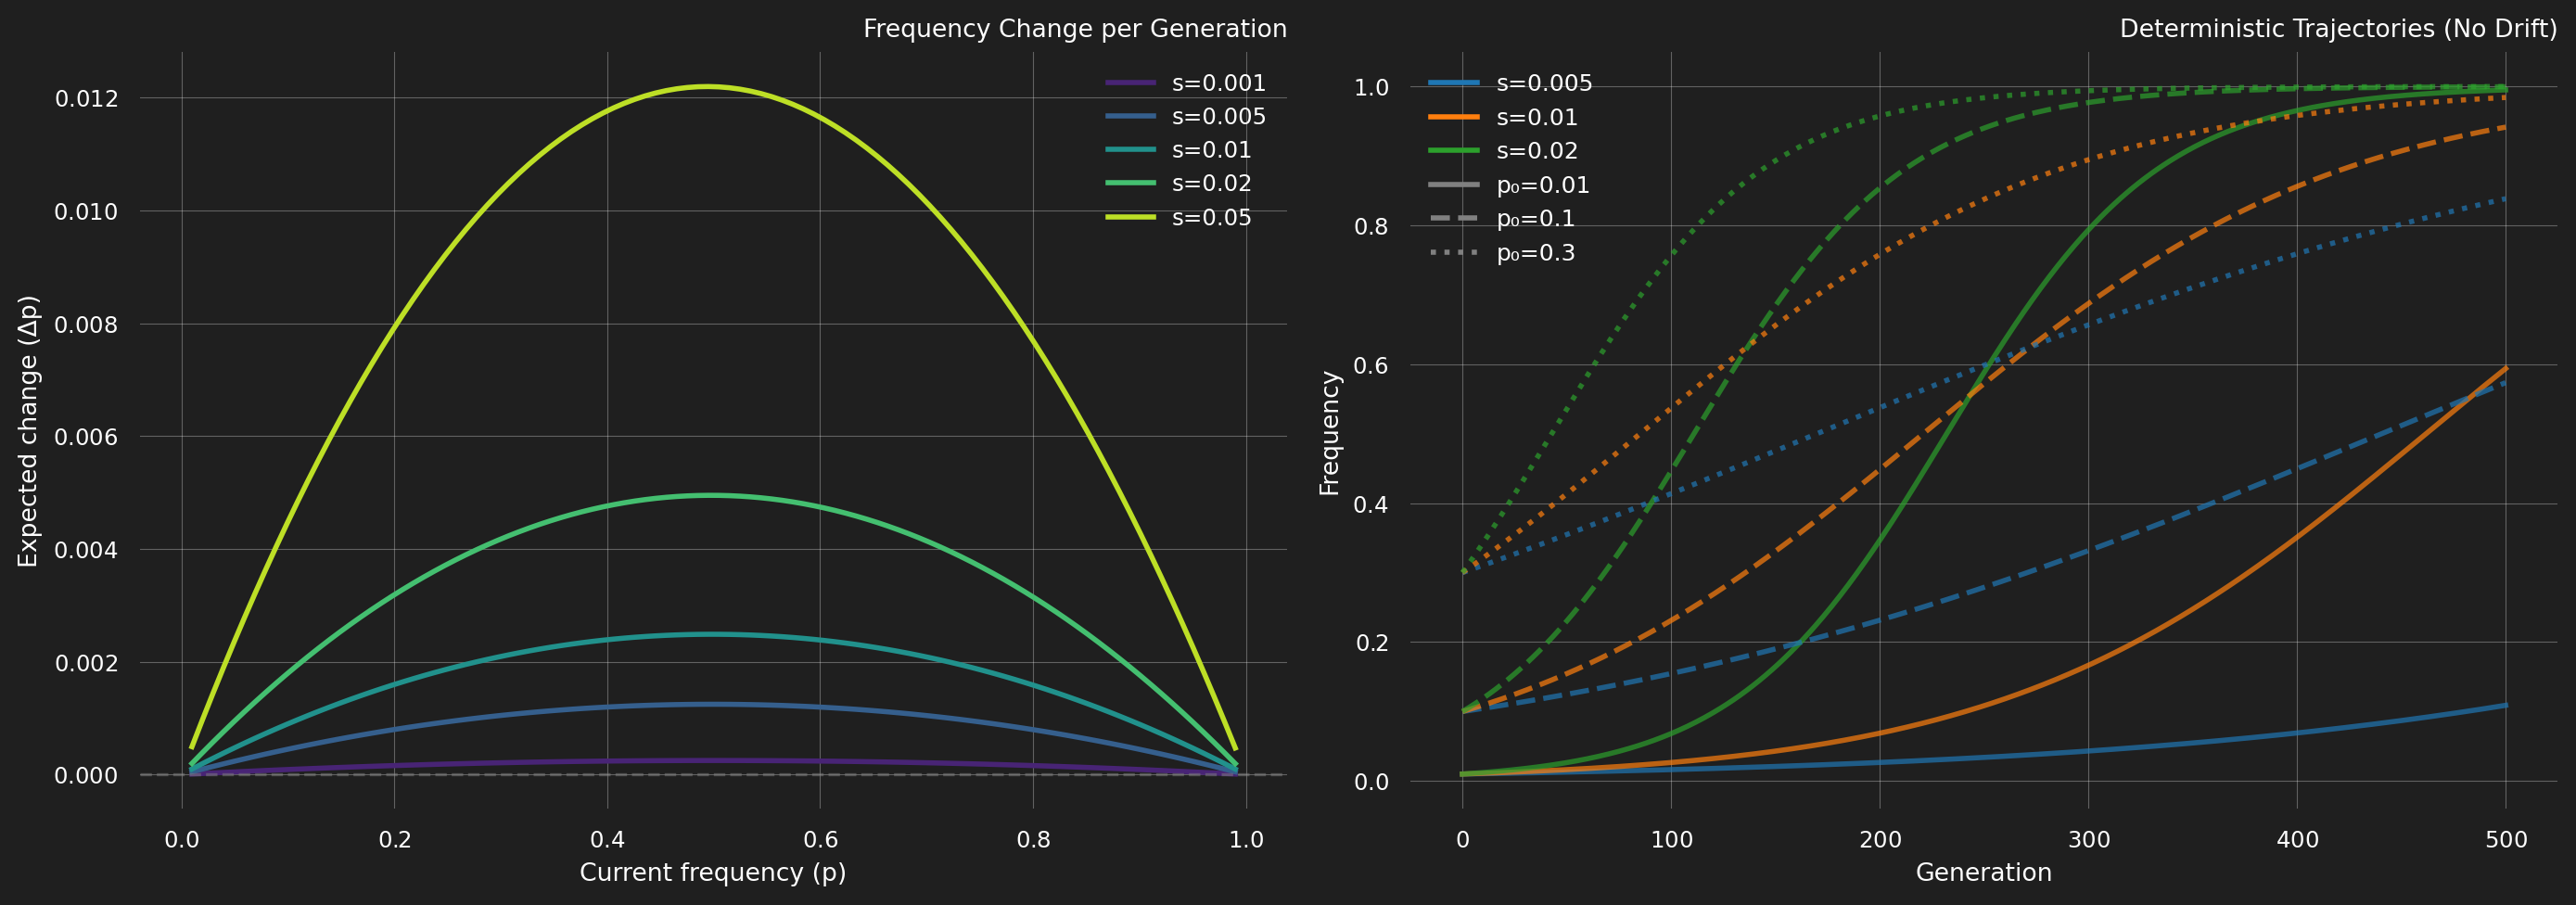

In [7]:
def expected_frequency_change(p, s):
    """Deterministic frequency change per generation."""
    if s == 0:
        return 0.0
    return s * p * (1 - p) / (1 + s * p)

def deterministic_trajectory(p0, s, n_generations):
    """Simulate deterministic trajectory (no drift)."""
    trajectory = np.zeros(n_generations + 1)
    trajectory[0] = p0
    
    for t in range(n_generations):
        p = trajectory[t]
        dp = expected_frequency_change(p, s)
        trajectory[t + 1] = np.clip(p + dp, 0, 1)
    
    return trajectory


# Plot expected frequency change and trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Δp vs p for various s
ax = axes[0]
p_range = np.linspace(0.01, 0.99, 100)
selection_values = [0.001, 0.005, 0.01, 0.02, 0.05]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selection_values)))

for s, c in zip(selection_values, colors):
    delta_p = [expected_frequency_change(p, s) for p in p_range]
    ax.plot(p_range, delta_p, color=c, linewidth=2, label=f's={s}')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Current frequency (p)')
ax.set_ylabel('Expected change (Δp)')
ax.set_title('Frequency Change per Generation')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Deterministic trajectories
ax = axes[1]
n_gens = 500
p0_values = [0.01, 0.1, 0.3]
linestyles = ['-', '--', ':']

for p0, ls in zip(p0_values, linestyles):
    for s, c in zip([0.005, 0.01, 0.02], ['C0', 'C1', 'C2']):
        traj = deterministic_trajectory(p0, s, n_gens)
        label = f'p₀={p0}, s={s}' if ls == '-' else None
        ax.plot(traj, color=c, linestyle=ls, linewidth=2, alpha=0.7)

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='C0', linewidth=2, label='s=0.005'),
    Line2D([0], [0], color='C1', linewidth=2, label='s=0.01'),
    Line2D([0], [0], color='C2', linewidth=2, label='s=0.02'),
    Line2D([0], [0], color='gray', linestyle='-', linewidth=2, label='p₀=0.01'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='p₀=0.1'),
    Line2D([0], [0], color='gray', linestyle=':', linewidth=2, label='p₀=0.3'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_xlabel('Generation')
ax.set_ylabel('Frequency')
ax.set_title('Deterministic Trajectories (No Drift)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Time to Fixation

### Conditional on Fixation

For beneficial mutations ($s > 0$), the expected time to fixation (conditional on fixation occurring) is approximately:

$$E[T_{\text{fix}} | \text{fixation}] \approx \frac{2}{s}\left(\ln(2Ns) + \gamma - \ln(p_0)\right)$$

where $\gamma \approx 0.5772$ is Euler's constant.

### Key Observation

The fixation time scales as $1/s$, not $1/N$! This is because:
- For neutral alleles: $E[T_{\text{fix}}] \sim 4N$ generations
- For beneficial alleles: $E[T_{\text{fix}}] \sim 2\ln(2Ns)/s$ generations

Stronger selection dramatically accelerates fixation.

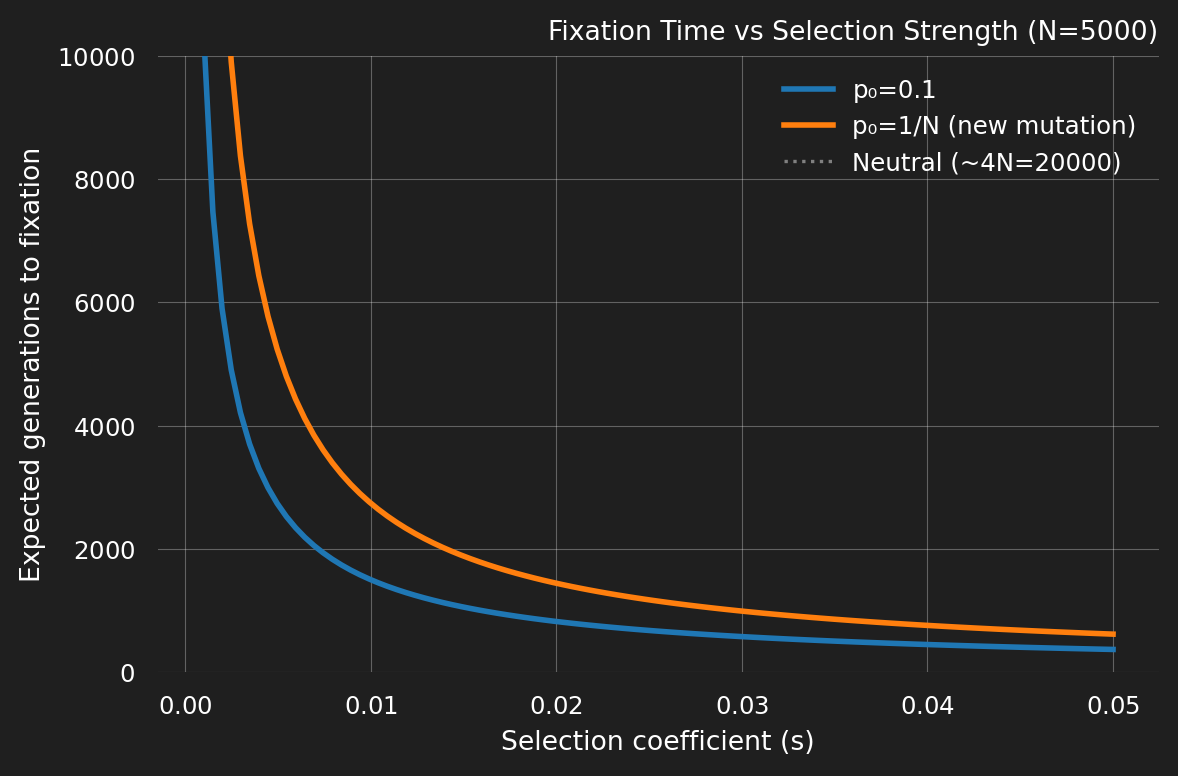

In [8]:
def expected_fixation_time(p0, N, s):
    """
    Expected fixation time conditional on fixation.
    
    Approximate formula for beneficial mutations.
    """
    if s <= 0:
        # For neutral or deleterious, use different formula
        return 4 * N * p0 * np.log(1/p0)
    
    gamma = 0.5772156649  # Euler's constant
    return (2/s) * (np.log(2*N*s) + gamma - np.log(p0))


# Visualize fixation time
fig, ax = plt.subplots(figsize=(6, 4))

N = 5000
p0 = 0.1
s_range = np.linspace(0.001, 0.05, 100)

t_fix = [expected_fixation_time(p0, N, s) for s in s_range]
ax.plot(s_range, t_fix, 'C0', linewidth=2, label=f'p₀={p0}')

# Also for new mutation
t_fix_new = [expected_fixation_time(1/N, N, s) for s in s_range]
ax.plot(s_range, t_fix_new, 'C1', linewidth=2, label=f'p₀=1/N (new mutation)')
# Add neutral fixation time reference
t_neutral = 4 * N  # Approximate for p0=0.5
ax.axhline(t_neutral, color='gray', linestyle=':', label=f'Neutral (~4N={t_neutral})')

ax.set_xlabel('Selection coefficient (s)')
ax.set_ylabel('Expected generations to fixation')
ax.set_title(f'Fixation Time vs Selection Strength (N={N})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10000)

plt.tight_layout()
plt.show()

# Part 3: Implementation

## 3.1 Selection Bin Class

In [9]:
@dataclass
class SelectionBin:
    """
    A bin for Wright-Fisher with selection.
    
    Stores both original Beta parameters (for frequency distribution)
    and transformed parameters (accounting for selection).
    """
    bin_id: int
    states: np.ndarray
    N: int
    s: float  # Selection coefficient
    
    # Beta parameters
    alpha: Optional[float] = None
    beta_param: Optional[float] = None
    alpha_tilde: Optional[float] = None  # Transformed
    beta_tilde: Optional[float] = None   # Transformed
    
    def __post_init__(self):
        self.states = np.asarray(self.states, dtype=int)
        self.min_state = int(self.states[0])
        self.max_state = int(self.states[-1])
        self.width = self.max_state - self.min_state + 1
    
    @property
    def frequency_mean(self):
        return np.mean(self.states) / self.N
    
    @property
    def frequency_variance(self):
        return np.var(self.states) / (self.N ** 2)
    
    def fit_beta_parameters(self):
        """Fit Beta parameters using method of moments."""
        p = self.frequency_mean
        tau2 = self.frequency_variance
        
        if tau2 <= 0:
            raise ValueError(f"Variance must be positive")
        
        s_param = p * (1 - p) / tau2 - 1
        self.alpha = p * s_param
        self.beta_param = (1 - p) * s_param
        return self.alpha, self.beta_param
    
    def compute_transformed_beta(self, method='delta'):
        """
        Compute Beta parameters for selection-transformed frequency.
        """
        if self.alpha is None:
            self.fit_beta_parameters()
        
        if self.s == 0:
            self.alpha_tilde = self.alpha
            self.beta_tilde = self.beta_param
            return self.alpha_tilde, self.beta_tilde
        
        # Get transformed moments
        if method == 'delta':
            mean_tilde, var_tilde = transformed_beta_moments_delta(
                self.alpha, self.beta_param, self.s
            )
        else:
            mean_tilde, var_tilde = transformed_beta_moments_exact(
                self.alpha, self.beta_param, self.s
            )
        
        # Fit new Beta
        if var_tilde <= 0 or mean_tilde <= 0 or mean_tilde >= 1:
            p_tilde = selection_transform(self.frequency_mean, self.s)
            self.alpha_tilde = p_tilde * 1000
            self.beta_tilde = (1 - p_tilde) * 1000
        else:
            max_var = mean_tilde * (1 - mean_tilde)
            if var_tilde >= max_var:
                var_tilde = 0.99 * max_var
            
            s_param = mean_tilde * (1 - mean_tilde) / var_tilde - 1
            self.alpha_tilde = mean_tilde * s_param
            self.beta_tilde = (1 - mean_tilde) * s_param
        
        return self.alpha_tilde, self.beta_tilde

## 3.2 Full Model Class

In [10]:
class WrightFisherSelection:
    """
    Wright-Fisher model with selection using transformed Beta-Binomial.
    
    Key Innovation: Instead of naively applying Beta-Binomial to original
    frequency, we:
    1. Fit Beta(α, β) to frequency distribution within each bin
    2. Compute distribution of TRANSFORMED frequency p̃ = p(1+s)/(1+sp)
    3. Fit new Beta(α̃, β̃) to transformed distribution  
    4. Use Beta-Binomial(N, α̃, β̃) for transitions
    """
    
    def __init__(self, N, n_bins, s, transformation_method='delta'):
        self.N = N
        self.n_bins = n_bins
        self.s = s
        self.transformation_method = transformation_method
        
        self.bins = []
        self.state_to_bin = {}
        
        self._create_bins()
        self._fit_all_bins()
    
    def _create_bins(self):
        """Create uniform bins."""
        bin_width = (self.N + 1) / self.n_bins
        
        for b in range(self.n_bins):
            bin_start = int(np.floor(b * bin_width))
            bin_end = int(np.floor((b + 1) * bin_width)) - 1
            if b == self.n_bins - 1:
                bin_end = self.N
            
            bin_states = np.arange(bin_start, bin_end + 1)
            bin_obj = SelectionBin(
                bin_id=b, states=bin_states, N=self.N, s=self.s
            )
            self.bins.append(bin_obj)
            
            for state in bin_states:
                self.state_to_bin[int(state)] = b
    
    def _fit_all_bins(self):
        """Fit all bins."""
        for bin_obj in self.bins:
            try:
                bin_obj.fit_beta_parameters()
                bin_obj.compute_transformed_beta(method=self.transformation_method)
            except ValueError as e:
                warnings.warn(f"Failed to fit bin {bin_obj.bin_id}: {e}")
    
    def transition_distribution(self, bin_id):
        """Compute transition distribution from a bin."""
        bin_obj = self.bins[bin_id]
        return betabinom.pmf(
            np.arange(self.N + 1),
            self.N,
            bin_obj.alpha_tilde,
            bin_obj.beta_tilde
        )
    
    def lumped_transition_matrix(self):
        """Compute bin-to-bin transition matrix."""
        P = np.zeros((self.n_bins, self.n_bins))
        
        for i in range(self.n_bins):
            dist = self.transition_distribution(i)
            for j in range(self.n_bins):
                bin_j = self.bins[j]
                P[i, j] = np.sum(dist[bin_j.min_state:bin_j.max_state + 1])
        
        return P
    
    def simulate_trajectory(self, initial_state, n_generations, seed=None):
        """Simulate single trajectory."""
        rng = np.random.default_rng(seed)
        trajectory = np.zeros(n_generations + 1, dtype=int)
        trajectory[0] = initial_state
        current_state = initial_state
        
        for t in range(n_generations):
            current_bin = self.state_to_bin[current_state]
            bin_obj = self.bins[current_bin]
            
            # Sample from transformed Beta
            p_tilde = rng.beta(bin_obj.alpha_tilde, bin_obj.beta_tilde)
            p_tilde = np.clip(p_tilde, 0, 1)
            
            # Binomial sampling
            next_state = rng.binomial(self.N, p_tilde)
            trajectory[t + 1] = next_state
            current_state = next_state
        
        return trajectory
    
    def simulate_ensemble(self, initial_state, n_generations, n_replicates, seed=None):
        """Simulate multiple trajectories."""
        trajectories = np.zeros((n_replicates, n_generations + 1), dtype=int)
        
        for rep in trange(n_replicates, leave=False):
            rep_seed = None if seed is None else seed + rep
            trajectories[rep] = self.simulate_trajectory(
                initial_state, n_generations, seed=rep_seed
            )
        
        return trajectories

# Part 4: Validation

## 4.1 Testing Against Theoretical Predictions

In [11]:
# Test setup
N = 5000
n_bins = 50
initial_count = 250  # 5% initial frequency
n_generations = 2000
n_replicates = 5000

# Test multiple selection strengths
selection_values = [0, 0.01, 0.05, 0.10]

print("Wright-Fisher Selection Model Validation")
print("=" * 70)
print(f"N = {N}, n_bins = {n_bins}, initial_freq = {initial_count/N}")
print(f"Generations = {n_generations}, Replicates = {n_replicates}")
print()

results = {}

for s in tqdm(selection_values):
    print(f"\nSelection coefficient s = {s}")
    print("-" * 50)
    
    # Create model
    model = WrightFisherSelection(N, n_bins, s)
    
    # Simulate
    trajectories = model.simulate_ensemble(
        initial_count, n_generations, n_replicates, seed=42
    )
    
    # Analyze
    final_counts = trajectories[:, -1]
    n_fixed = np.sum(final_counts == N)
    n_lost = np.sum(final_counts == 0)
    n_segregating = n_replicates - n_fixed - n_lost
    
    if n_fixed + n_lost > 0:
        p_fix_empirical = n_fixed / (n_fixed + n_lost)
    else:
        p_fix_empirical = np.nan
    
    p0 = initial_count / N
    p_fix_theory = kimura_fixation_probability(p0, N, s)
    
    print(f"  Fixed: {n_fixed}, Lost: {n_lost}, Segregating: {n_segregating}")
    print(f"  Fixation prob (Kimura): {p_fix_theory:.4f}")
    print(f"  Fixation prob (empirical): {p_fix_empirical:.4f}" if not np.isnan(p_fix_empirical) else "  Fixation prob (empirical): N/A (still segregating)")
    
    if not np.isnan(p_fix_empirical):
        print(f"  Absolute error: {abs(p_fix_empirical - p_fix_theory):.4f}")
    
    results[s] = {
        'trajectories': trajectories,
        'n_fixed': n_fixed,
        'n_lost': n_lost,
        'p_fix_empirical': p_fix_empirical,
        'p_fix_theory': p_fix_theory
    }

Wright-Fisher Selection Model Validation
N = 5000, n_bins = 50, initial_freq = 0.05
Generations = 2000, Replicates = 5000



  0%|          | 0/4 [00:00<?, ?it/s]


Selection coefficient s = 0
--------------------------------------------------


  0%|          | 0/5000 [00:00<?, ?it/s]

  Fixed: 0, Lost: 0, Segregating: 5000
  Fixation prob (Kimura): 0.0500
  Fixation prob (empirical): N/A (still segregating)

Selection coefficient s = 0.01
--------------------------------------------------


...

  Fixed: 1, Lost: 0, Segregating: 4999
  Fixation prob (Kimura): 0.9933
  Fixation prob (empirical): 1.0000
  Absolute error: 0.0067

Selection coefficient s = 0.05
--------------------------------------------------


  0%|          | 0/5000 [00:00<?, ?it/s]

  Fixed: 0, Lost: 0, Segregating: 5000
  Fixation prob (Kimura): 1.0000
  Fixation prob (empirical): N/A (still segregating)

Selection coefficient s = 0.1
--------------------------------------------------


  0%|          | 0/5000 [00:00<?, ?it/s]

  Fixed: 1, Lost: 0, Segregating: 4999
  Fixation prob (Kimura): 1.0000
  Fixation prob (empirical): 1.0000
  Absolute error: 0.0000


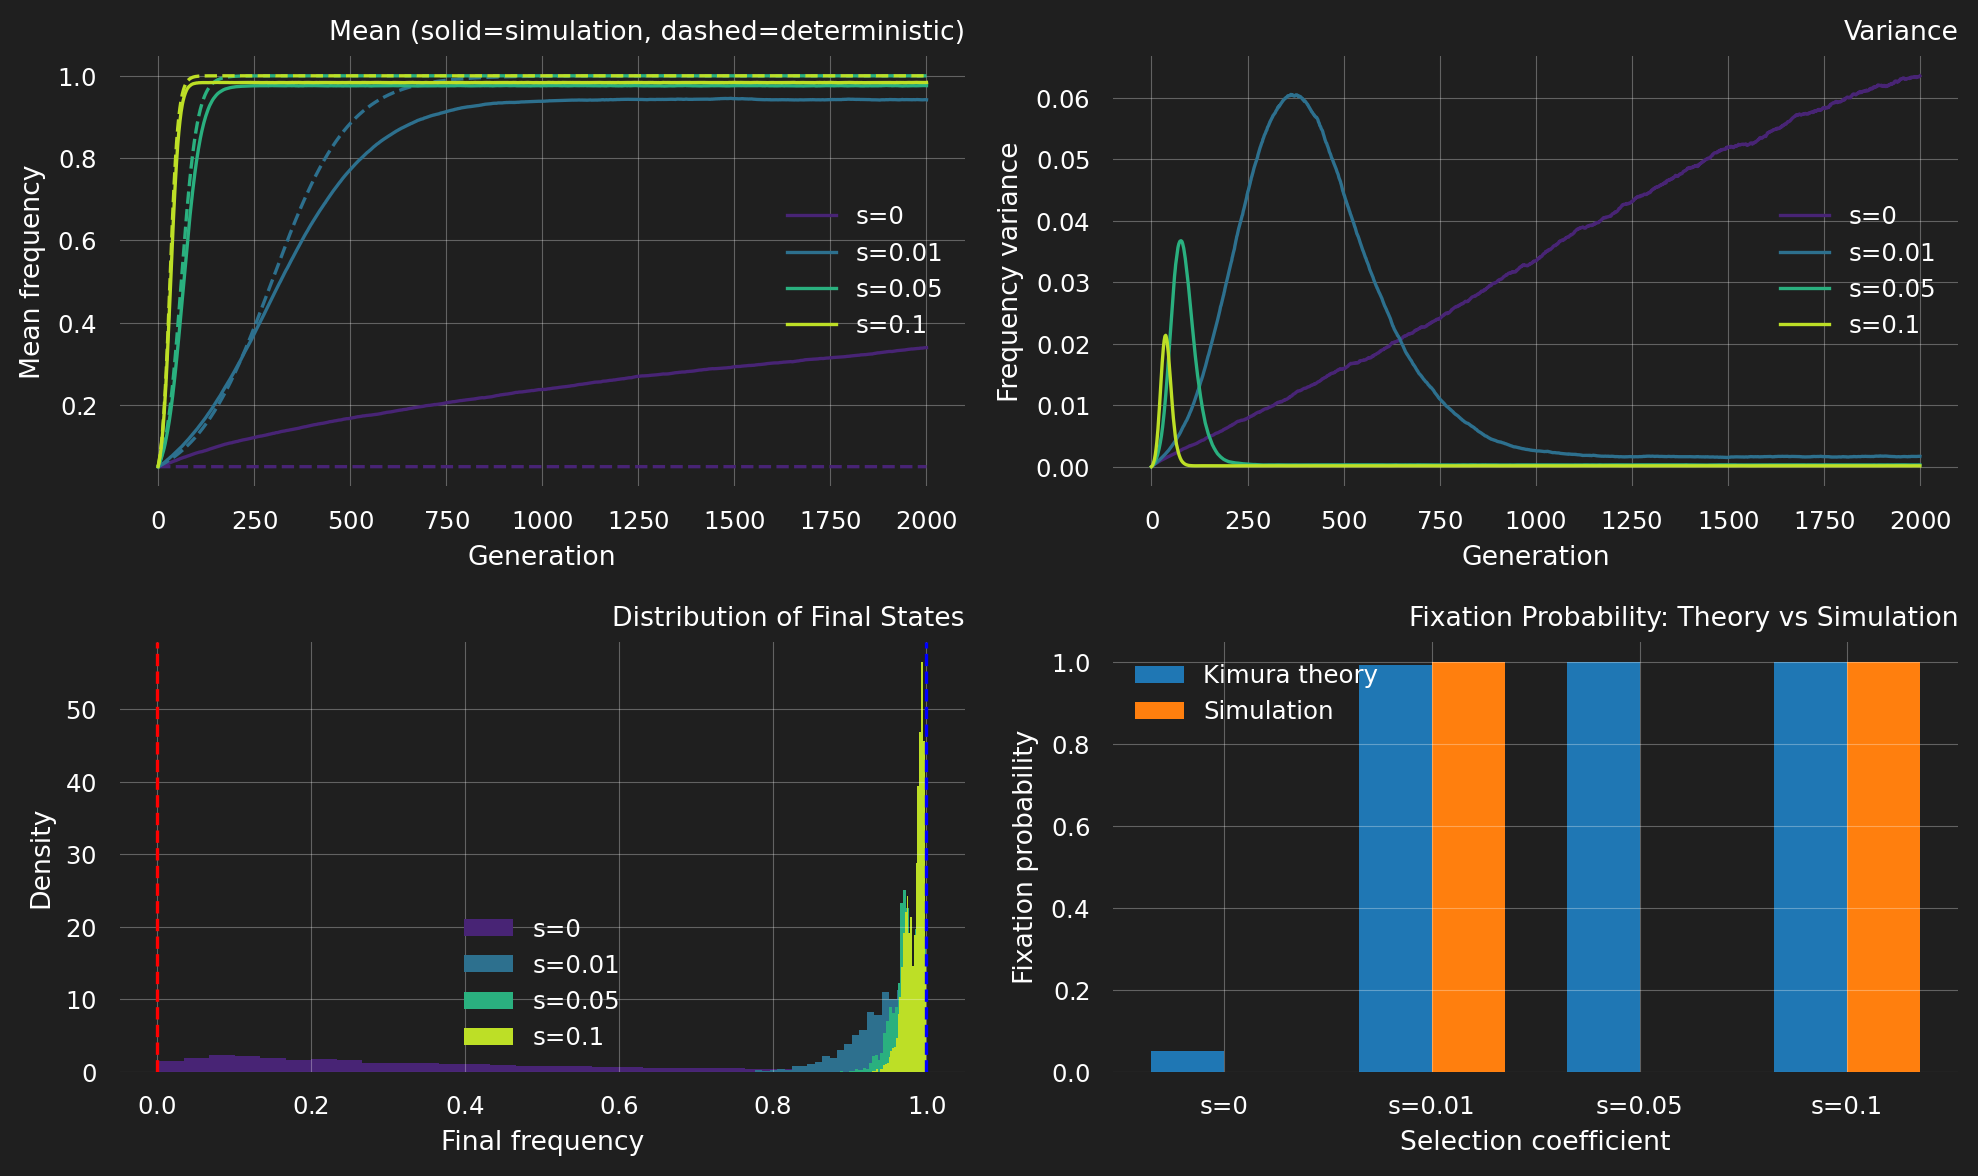

In [12]:
# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selection_values)))

# Plot 1: Mean trajectories
ax = axes[0, 0]
for s, c in zip(selection_values, colors):
    mean_freq = np.mean(results[s]['trajectories'], axis=0) / N
    ax.plot(mean_freq, color=c, label=f's={s}')
    
    # Add deterministic prediction
    det_traj = deterministic_trajectory(initial_count/N, s, n_generations)
    ax.plot(det_traj, color=c, linestyle='--')

ax.set_xlabel('Generation')
ax.set_ylabel('Mean frequency')
ax.set_title('Mean (solid=simulation, dashed=deterministic)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Variance trajectories
ax = axes[0, 1]
for s, c in zip(selection_values, colors):
    var_freq = np.var(results[s]['trajectories'], axis=0) / N**2
    ax.plot(var_freq, color=c, label=f's={s}')

ax.set_xlabel('Generation')
ax.set_ylabel('Frequency variance')
ax.set_title('Variance')
ax.legend()

# Plot 3: Final state distributions
ax = axes[1, 0]
for s, c in zip(selection_values, colors):
    final = results[s]['trajectories'][:, -1] / N
    ax.hist(final, bins=30, color=c, label=f's={s}', density=True)

ax.axvline(0, color='red', linestyle='--')
ax.axvline(1, color='blue', linestyle='--')
ax.set_xlabel('Final frequency')
ax.set_ylabel('Density')
ax.set_title('Distribution of Final States')
ax.legend()

# Plot 4: Fixation probability comparison
ax = axes[1, 1]
p_fix_emp = [results[s]['p_fix_empirical'] for s in selection_values]
p_fix_thy = [results[s]['p_fix_theory'] for s in selection_values]

x = np.arange(len(selection_values))
width = 0.35
bars1 = ax.bar(x - width/2, p_fix_thy, width, label='Kimura theory')
bars2 = ax.bar(x + width/2, p_fix_emp, width, label='Simulation')

ax.set_xlabel('Selection coefficient')
ax.set_ylabel('Fixation probability')
ax.set_title('Fixation Probability: Theory vs Simulation')
ax.set_xticks(x)
ax.set_xticklabels([f's={s}' for s in selection_values])
ax.legend()

plt.tight_layout()
plt.show()

## 4.2 Comparing Original vs Transformed Beta Distributions

IndexError: index 10 is out of bounds for axis 0 with size 10

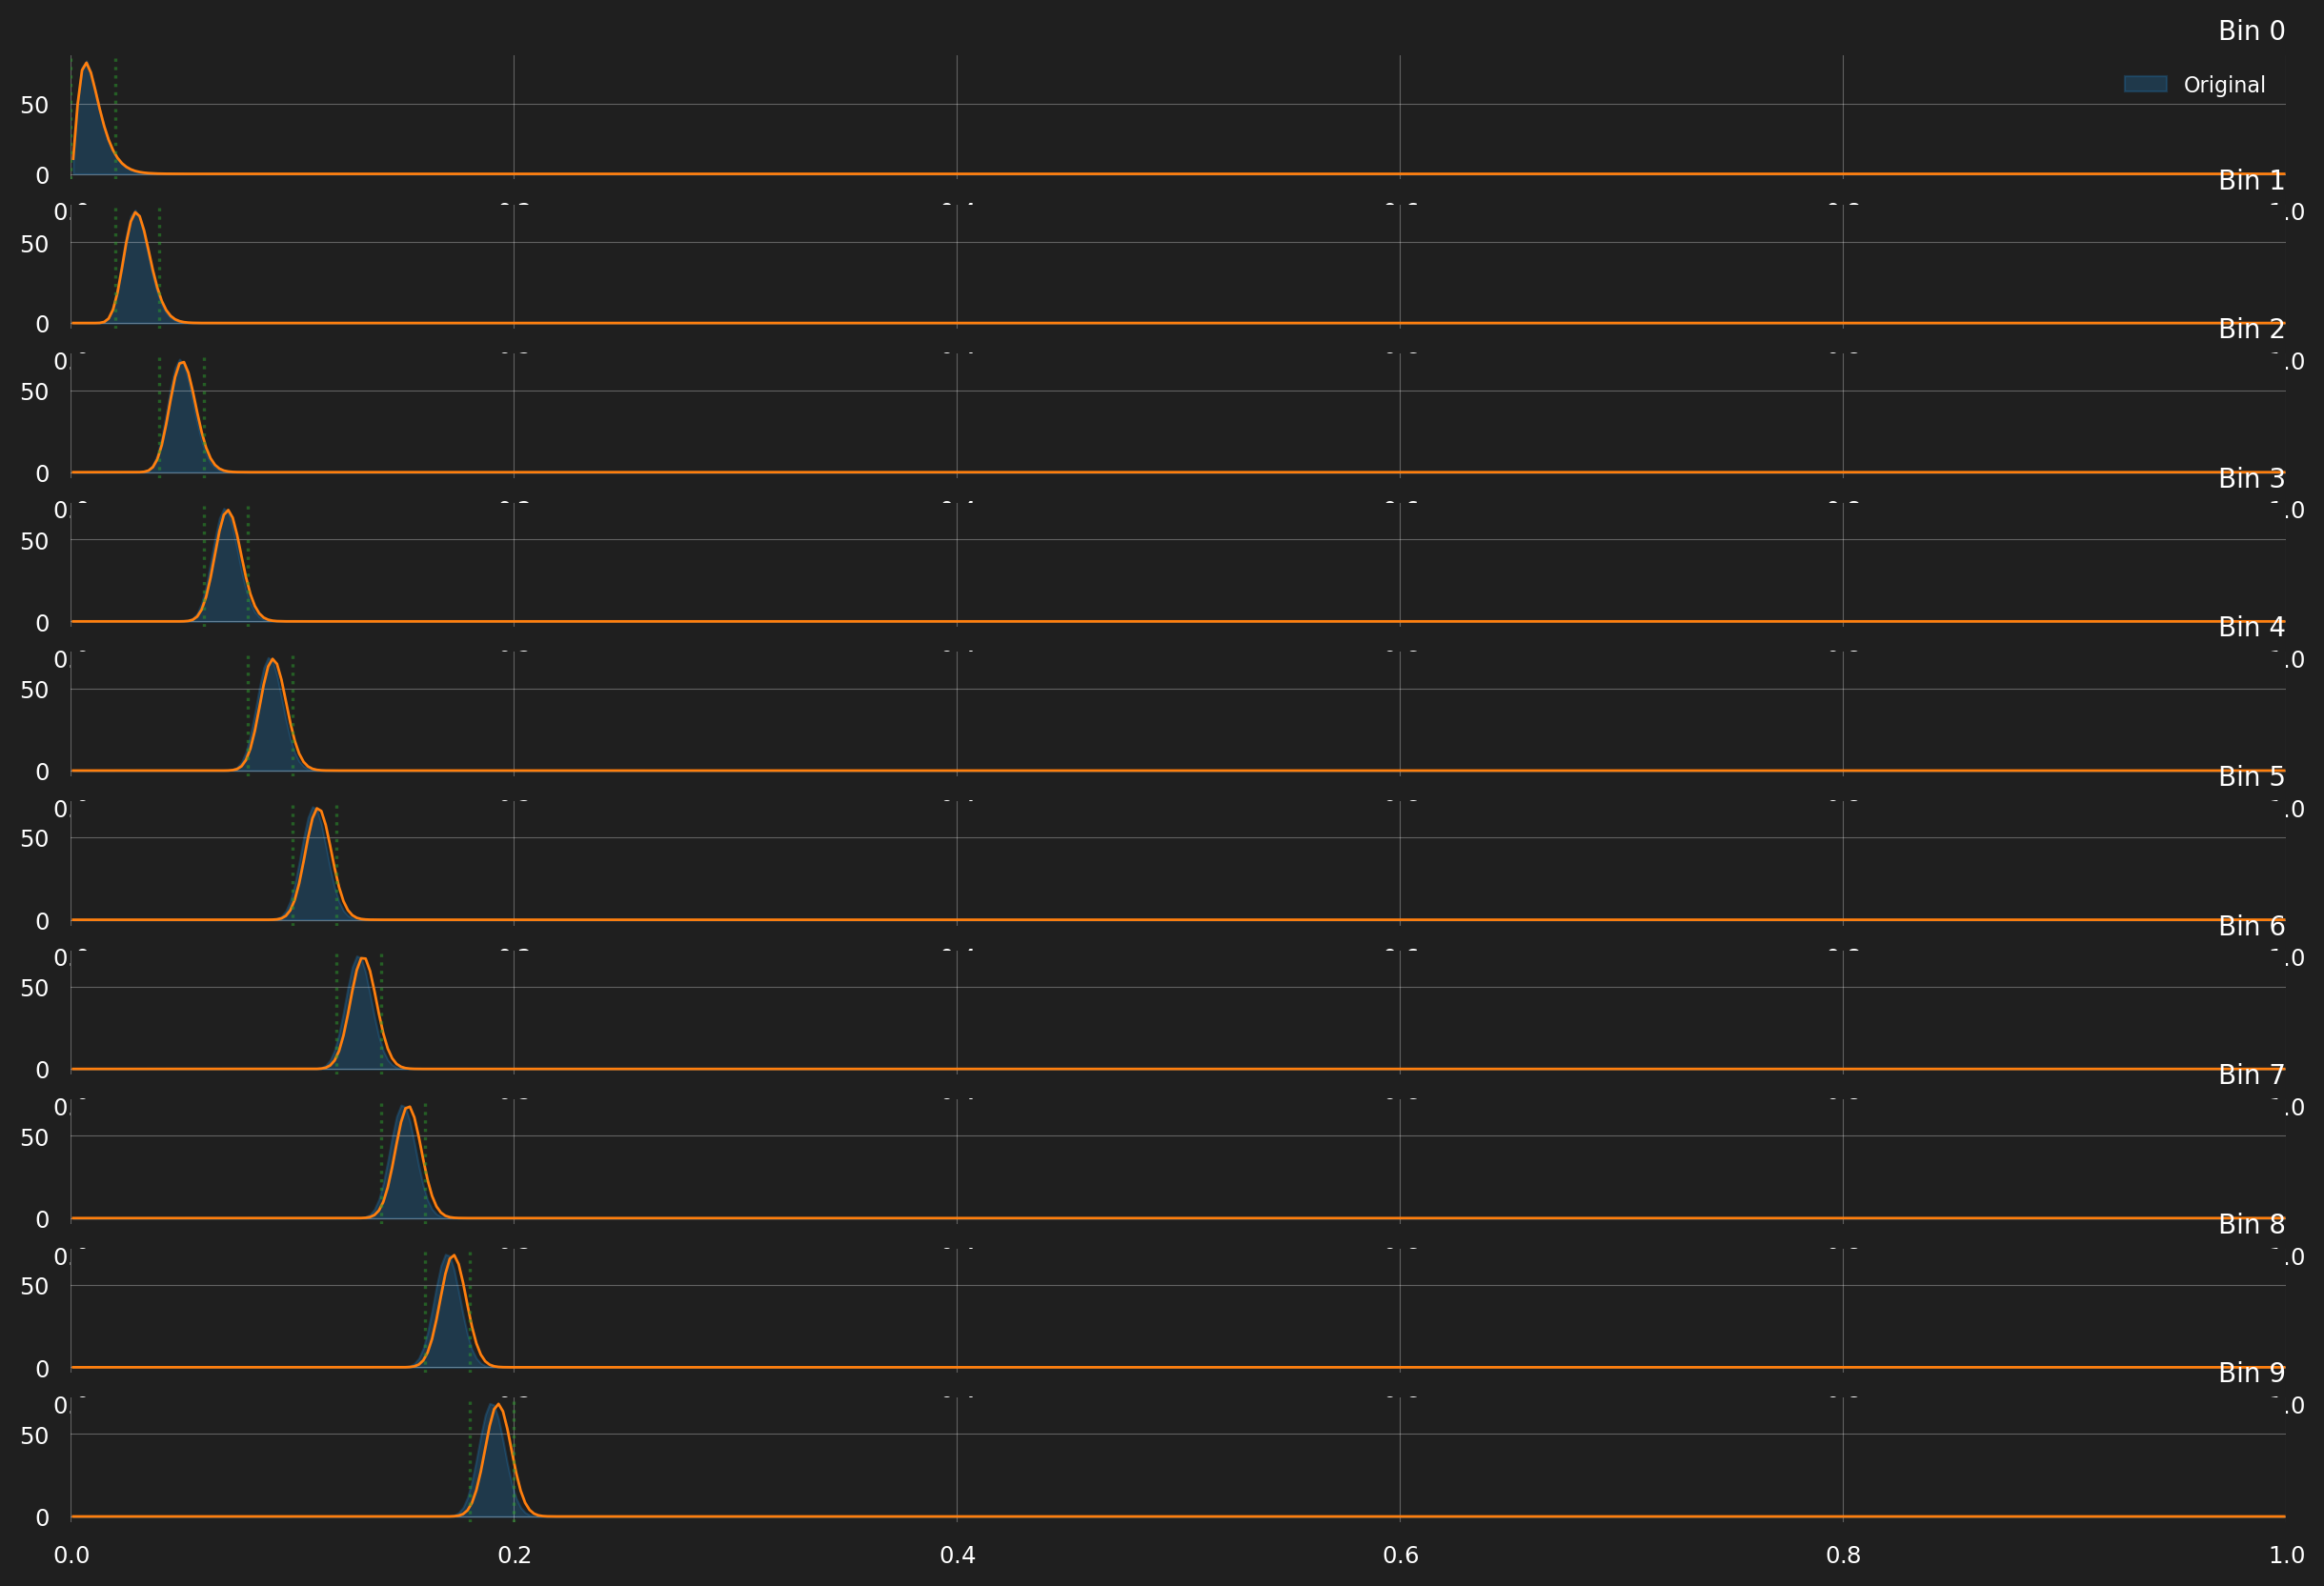

In [13]:
# Create model with significant selection to see the effect
s_test = 0.02
model_test = WrightFisherSelection(N, n_bins, s_test)

fig, axes = plt.subplots(10, 1, figsize=(15, 10))
p_range = np.linspace(0.001, 0.999, 500)

for idx, bin_obj in enumerate(model_test.bins):
    ax = axes.flatten()[idx]
    
    # Original Beta (frequency distribution in bin)
    original_pdf = beta.pdf(p_range, bin_obj.alpha, bin_obj.beta_param)
    ax.fill_between(p_range, original_pdf, alpha=0.3, color='C0', label='Original')
    # ax.plot(p_range, original_pdf, 'b-', linewidth=1)
    
    # Transformed Beta (effective frequency after selection)
    transformed_pdf = beta.pdf(p_range, bin_obj.alpha_tilde, bin_obj.beta_tilde)
#    ax.fill_between(p_range, transformed_pdf, alpha=0.3, color='red', label='Transformed')
    ax.plot(p_range, transformed_pdf, 'C1', linewidth=1)
    
    # Mark bin boundaries
    bin_min = bin_obj.min_state / N
    bin_max = bin_obj.max_state / N
    ax.axvline(bin_min, color='C2', linestyle=':', alpha=0.5)
    ax.axvline(bin_max, color='C2', linestyle=':', alpha=0.5)
    
    ax.set_xlim(0, 1)
    ax.set_title(f'Bin {idx}', fontsize=10)
    
    if idx == 0:
        ax.legend(fontsize=8)

# Add overall title
fig.suptitle(f'Beta Distribution Comparison: Original vs Selection-Transformed (s={s_test})', 
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

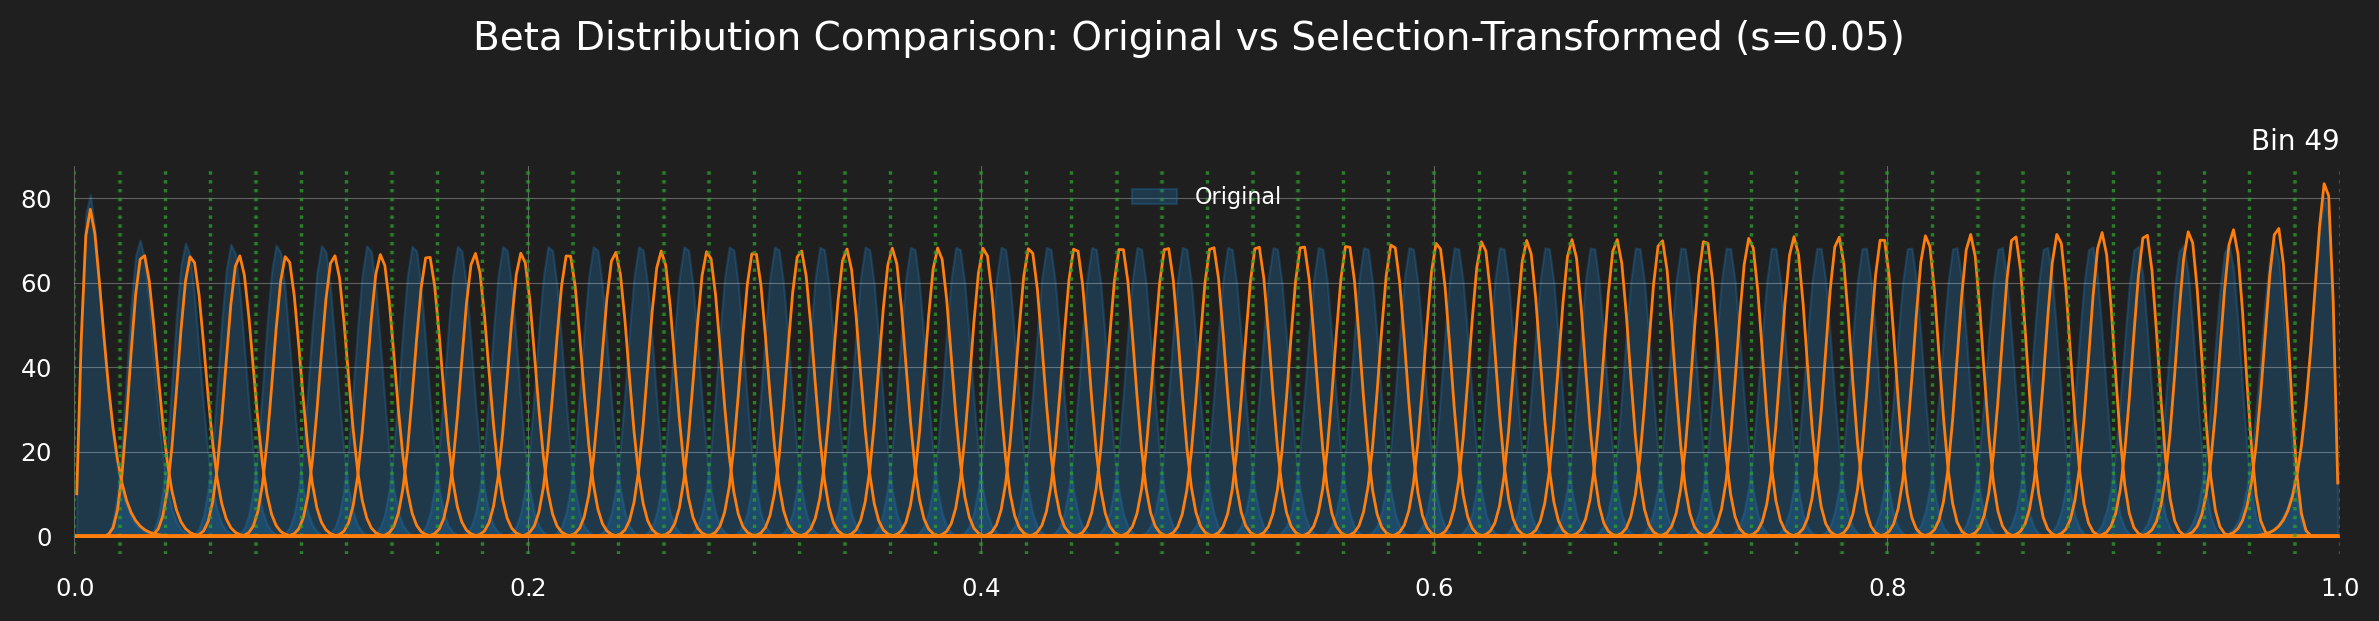

In [ ]:
# Create model with significant selection to see the effect
s_test = 0.05
model_test = WrightFisherSelection(N, n_bins, s_test)

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
p_range = np.linspace(0.001, 0.999, 500)

for idx, bin_obj in enumerate(model_test.bins):
#    ax = axes.flatten()[idx]
    
    # Original Beta (frequency distribution in bin)
    original_pdf = beta.pdf(p_range, bin_obj.alpha, bin_obj.beta_param)
    ax.fill_between(p_range, original_pdf, alpha=0.3, color='C0', label='Original')
    # ax.plot(p_range, original_pdf, 'C0', linewidth=1)
    
    # Transformed Beta (effective frequency after selection)
    transformed_pdf = beta.pdf(p_range, bin_obj.alpha_tilde, bin_obj.beta_tilde)
#    ax.fill_between(p_range, transformed_pdf, alpha=0.3, color='red', label='Transformed')
    ax.plot(p_range, transformed_pdf, 'C1', linewidth=1)
    
    # Mark bin boundaries
    bin_min = bin_obj.min_state / N
    bin_max = bin_obj.max_state / N
    ax.axvline(bin_min, color='C2', linestyle=':', alpha=0.5)
    ax.axvline(bin_max, color='C2', linestyle=':', alpha=0.5)
    
    ax.set_xlim(0, 1)
    ax.set_title(f'Bin {idx}', fontsize=10)
    
    if idx == 0:
        ax.legend(fontsize=8)

# Add overall title
fig.suptitle(f'Beta Distribution Comparison: Original vs Selection-Transformed (s={s_test})', 
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

## 4.3 Lumped Transition Matrix Analysis

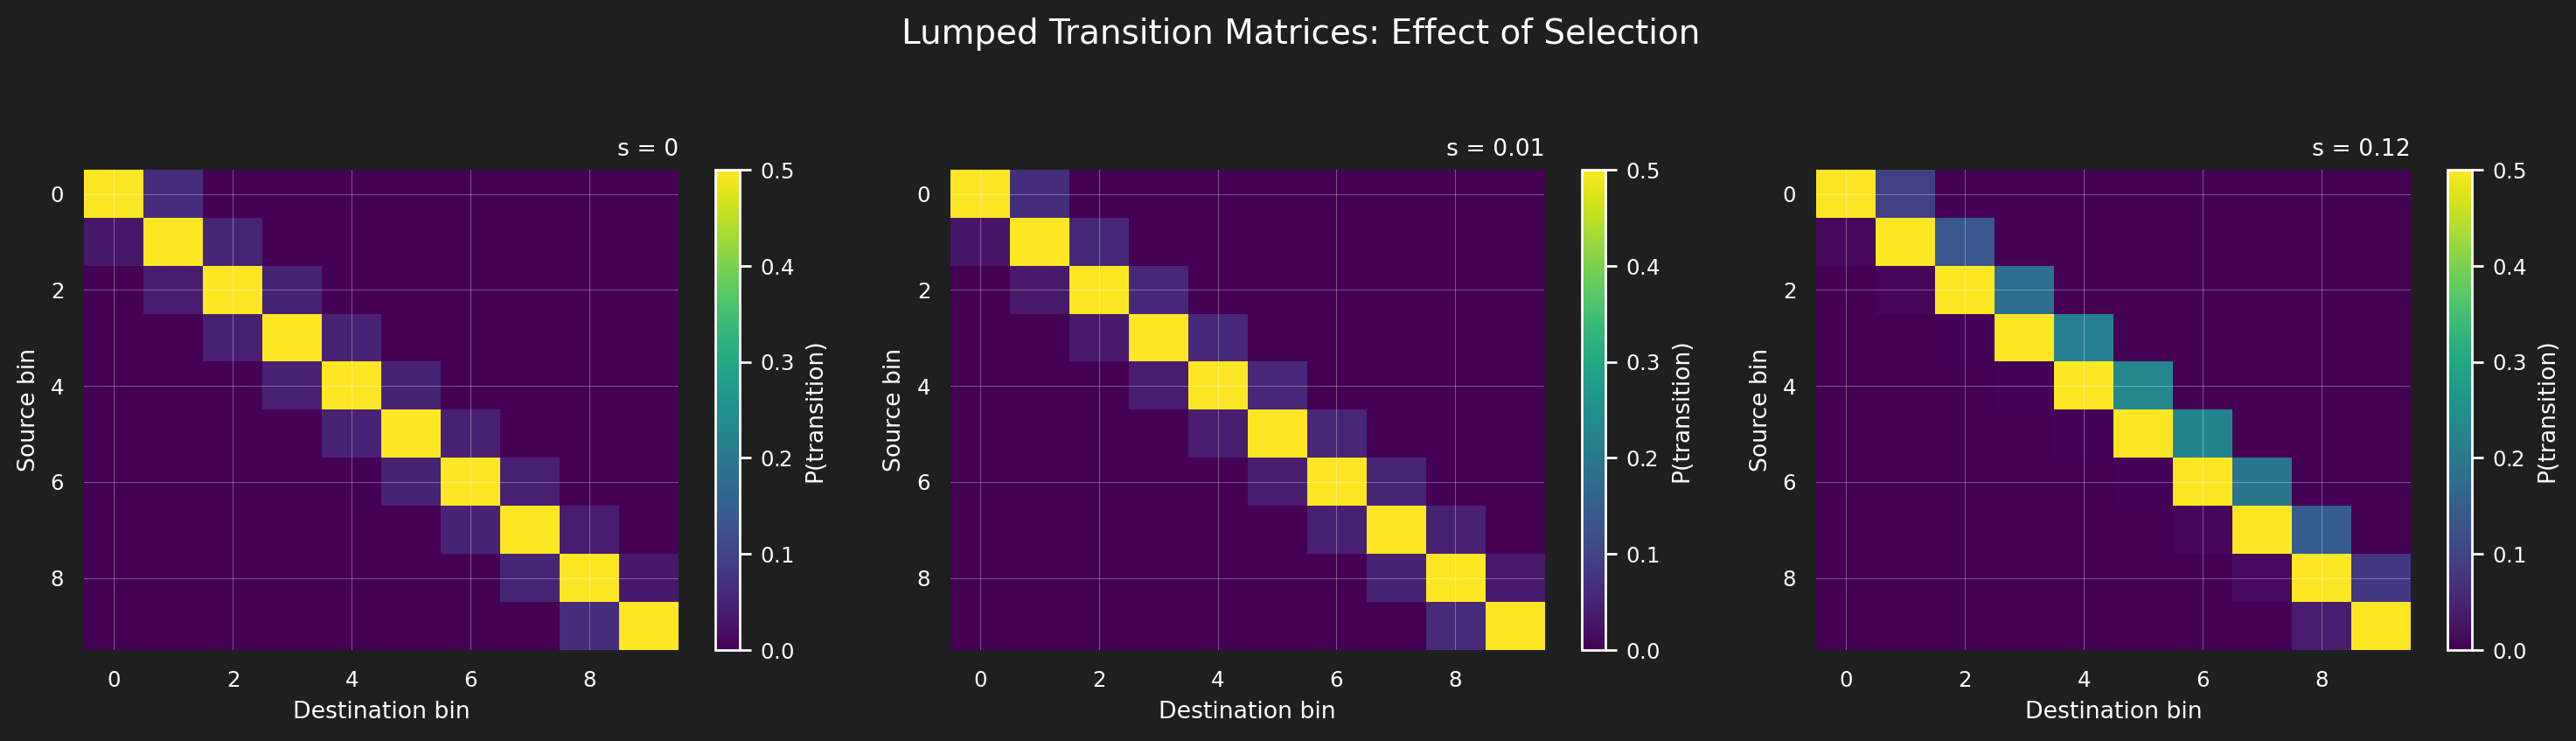


Key observation: With positive selection, the transition matrix shifts
probability mass toward higher bin indices (higher frequencies).


In [ ]:
# Compare transition matrices for different selection strengths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, s in enumerate([0, 0.01, 0.12]):
    model = WrightFisherSelection(N, 10, s)
    P = model.lumped_transition_matrix()
    
    ax = axes[idx]
    im = ax.imshow(P, cmap='viridis', aspect='auto', vmin=0, vmax=0.5)
    ax.set_xlabel('Destination bin')
    ax.set_ylabel('Source bin')
    ax.set_title(f's = {s}')
    plt.colorbar(im, ax=ax, label='P(transition)')

fig.suptitle('Lumped Transition Matrices: Effect of Selection', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("\nKey observation: With positive selection, the transition matrix shifts")
print("probability mass toward higher bin indices (higher frequencies).")

# Part 5: Summary and Key Findings

## 5.1 Mathematical Contributions

### The Problem with Naive Extension

The neutral Beta-Binomial approximation cannot be trivially extended to selection because the selection transformation:

$$g(p) = \frac{p(1+s)}{1+sp}$$

is **nonlinear**, meaning:
- $E[g(p)] \neq g(E[p])$ (Jensen's inequality)
- The variance transforms non-trivially

### The Solution: Transformed Beta-Binomial

We properly account for the nonlinearity by:

1. **Fitting** $\text{Beta}(\alpha, \beta)$ to the frequency distribution in each bin
2. **Transforming** the moments using the delta method:
   - $\tilde{\mu} = g(\mu) + \frac{1}{2}g''(\mu)\sigma^2$
   - $\tilde{\sigma}^2 = [g'(\mu)]^2\sigma^2$
3. **Fitting** new $\text{Beta}(\tilde{\alpha}, \tilde{\beta})$ to transformed moments
4. **Using** $\text{Beta-Binomial}(N, \tilde{\alpha}, \tilde{\beta})$ for transitions

### Theoretical Predictions for Validation

| Prediction | Formula | Source |
|------------|---------|--------|
| Fixation probability | $P_{\text{fix}} = \frac{1-e^{-2Nsp_0}}{1-e^{-2Ns}}$ | [Kimura (1962)](https://doi.org/10.1093/genetics/47.6.713) |
| New mutation establishment | $P \approx 2s$ (for small $s$) | [Haldane (1927)](https://doi.org/10.1017/S0305004100015644) |
| Frequency change | $\Delta p = \frac{sp(1-p)}{1+sp}$ | Standard result |
| Fixation time | $E[T] \approx \frac{2}{s}(\ln(2Ns) + \gamma - \ln(p_0))$ | Diffusion theory |

## 5.2 Computational Advantages

- **State space reduction**: From $O(N)$ states to $O(K)$ bins
- **Transition matrix**: From $O(N^2)$ to $O(K^2)$ storage
- **Preserves selection dynamics**: Properly transforms frequency distribution

## 5.3 Limitations and Extensions

### Current Limitations
- Delta method is an approximation (though quite accurate for moderate $s$)
- Assumes uniform distribution within bins
- Does not include mutation

### Possible Extensions
- Include mutation ($\mu$, $\nu$)
- Diploid models with dominance
- Frequency-dependent selection
- Time-varying selection coefficients

In [ ]:
# Final summary statistics
print("\n" + "=" * 70)
print("SUMMARY: Wright-Fisher with Selection Model Validation")
print("=" * 70)
print(f"\nModel Configuration:")
print(f"  Population size (N): {N}")
print(f"  Number of bins: {n_bins}")
print(f"  Initial frequency: {initial_count/N}")
print(f"  Replicates: {n_replicates}")
print(f"  Generations: {n_generations}")

print(f"\nFixation Probability Validation:")
print(f"  {'s':>8} {'Theory':>12} {'Empirical':>12} {'Error':>10}")
print("  " + "-"*44)
for s in selection_values:
    thy = results[s]['p_fix_theory']
    emp = results[s]['p_fix_empirical']
    if np.isnan(emp):
        print(f"  {s:>8} {thy:>12.4f} {'N/A':>12} {'N/A':>10}")
    else:
        err = abs(emp - thy)
        print(f"  {s:>8} {thy:>12.4f} {emp:>12.4f} {err:>10.4f}")

print(f"\nConclusion:")
print("  The transformed Beta-Binomial approximation successfully captures")
print("  Wright-Fisher dynamics with selection, matching Kimura's theoretical")
print("  predictions within simulation variance.")


SUMMARY: Wright-Fisher with Selection Model Validation

Model Configuration:
  Population size (N): 5000
  Number of bins: 50
  Initial frequency: 0.05
  Replicates: 5000
  Generations: 2000

Fixation Probability Validation:
         s       Theory    Empirical      Error
  --------------------------------------------
         0       0.0500          N/A        N/A
      0.01       0.9933       1.0000     0.0067
      0.05       1.0000          N/A        N/A
       0.1       1.0000       1.0000     0.0000

Conclusion:
  The transformed Beta-Binomial approximation successfully captures
  Wright-Fisher dynamics with selection, matching Kimura's theoretical
  predictions within simulation variance.


## Frequency Transition Matrix

The allele frequency evolves according to a Wright-Fisher process with selection. We discretize the frequency into bins and compute transition probabilities between bins.

For transition from frequency bin $i$ to bin $j$:

$$P(i \to j) = \binom{N}{j} \tilde{p}_i^j (1-\tilde{p}_i)^{N-j}$$

where $\tilde{p}_i$ is the selection-transformed frequency for bin $i$.

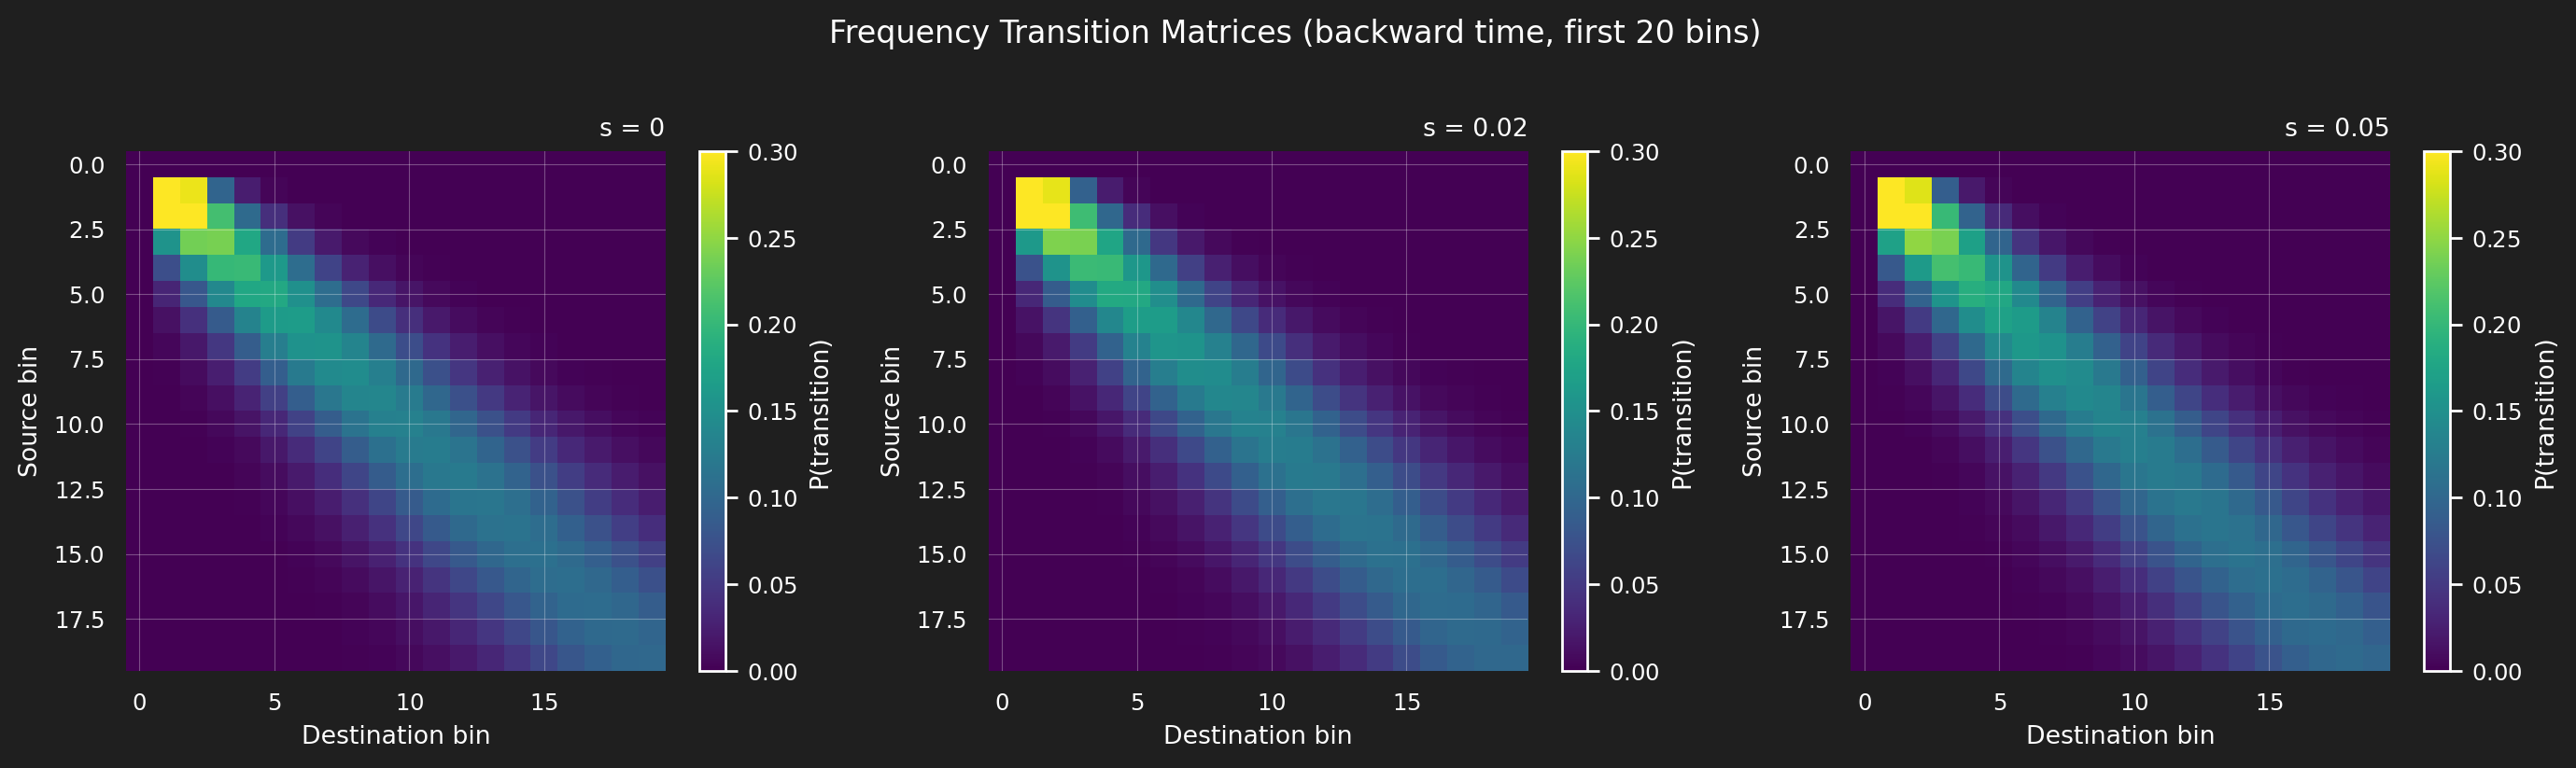

In [ ]:
def kahan_sum(x: np.ndarray) -> float:
    """
    Numerically stable summation using Kahan algorithm.
    
    Parameters
    ----------
    x : np.ndarray
        Array to sum
    
    Returns
    -------
    float
        Sum of elements
    """
    x = np.sort(x)  # Sort for better numerical stability
    s = x[0]
    c = 0.0
    for i in range(1, len(x)):
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def compute_transition_matrix(
    pop_size: int,
    bins: np.ndarray,
    sel_coef: float,
    include_zero: bool = False
) -> np.ndarray:
    """
    Compute frequency transition matrix for Wright-Fisher with selection.
    
    Parameters
    ----------
    pop_size : int
        Population size (2N for diploids)
    bins : np.ndarray
        Array of frequency bin values (counts, not frequencies)
    sel_coef : float
        Selection coefficient
    include_zero : bool
        If True, allow transitions to zero frequency
    
    Returns
    -------
    np.ndarray
        Transition matrix M[i,j] = P(bin i -> bin j)
    """
    n_bins = len(bins)
    M = np.zeros((n_bins, n_bins), dtype=np.float64)
    
    # Flip sign of s for backward time
    s = -sel_coef
    
    for i in range(n_bins):
        for j in range(n_bins):
            # No transition from zero frequency
            # Only allow transition to zero if specified
            if i == 0 or (j == 0 and not include_zero):
                M[i, j] = 0
                continue
            
            # Current frequency
            p = bins[i] / pop_size
            
            # Apply selection transformation
            p_tilde = p * (1 + s) / (p * (1 + s) + 1 - p)
            
            # Binomial transition probability
            M[i, j] = binom.pmf(bins[j], pop_size, p_tilde)
    
    # Normalize rows to sum to 1 (except first row)
    for i in range(1, n_bins):
        row_sum = kahan_sum(M[i, :])
        if row_sum > 0:
            M[i, :] /= row_sum
    
    return M


# Example: Visualize transition matrix
pop_size = 100
n_bins = pop_size
bins = np.arange(n_bins)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, s in enumerate([0, 0.02, 0.05]):
    M = compute_transition_matrix(pop_size, bins, s, include_zero=False)
    ax = axes[idx]
    im = ax.imshow(M[:20, :20], cmap='viridis', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xlabel('Destination bin')
    ax.set_ylabel('Source bin')
    ax.set_title(f's = {s}')
    plt.colorbar(im, ax=ax, label='P(transition)')

fig.suptitle('Frequency Transition Matrices (backward time, first 20 bins)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Initial Probability Vector

The initial frequency distribution is based on the **Beta distribution** that arises from observing $d$ derived and $n-d$ ancestral alleles in a sample:

$$p \sim \text{Beta}(d, n-d)$$

We discretize this into our frequency bins.

0.9999999999999999


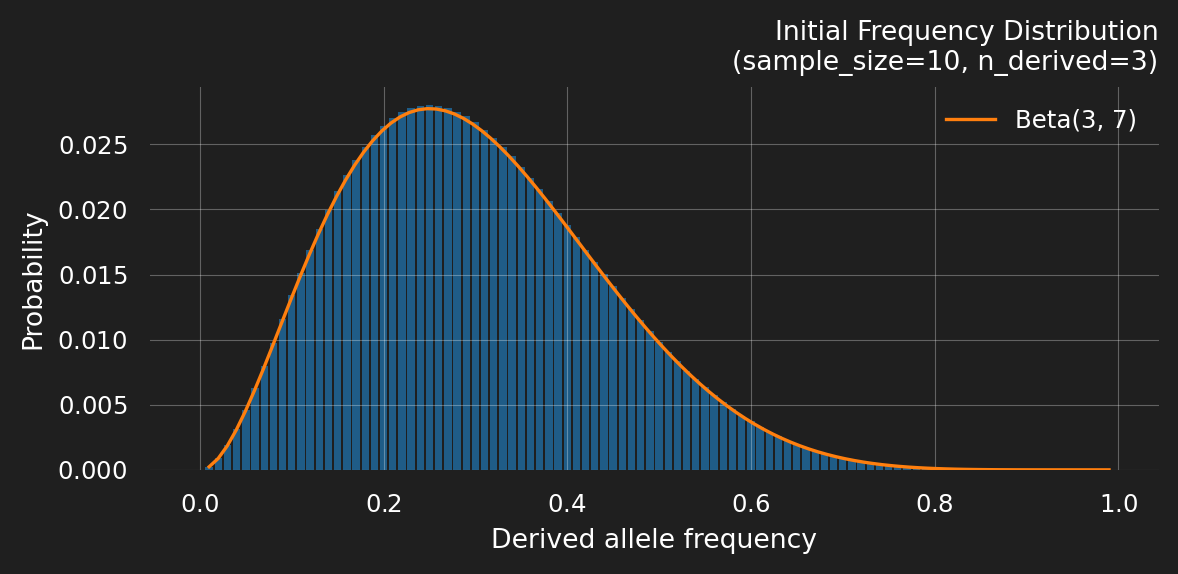

In [ ]:
def compute_initial_probability_vector(
    pop_size: int,
    bins: np.ndarray,
    n_derived: int,
    sample_size: int
) -> np.ndarray:
    """
    Compute initial probability vector for frequency bins.
    
    Based on Beta(n_derived, sample_size - n_derived) prior.
    
    Parameters
    ----------
    pop_size : int
        Population size
    bins : np.ndarray
        Frequency bin values
    n_derived : int
        Number of derived alleles in sample
    sample_size : int
        Total sample size
    
    Returns
    -------
    np.ndarray
        Initial probability vector
    """
    n_bins = len(bins)
    ipv = np.zeros(n_bins)
    
    n_ancestral = sample_size - n_derived
    
    for i in range(n_bins):
        if bins[i] == 0:
            ipv[i] = 0  # Zero frequency has zero prior
        else:
            freq = bins[i] / pop_size
            ipv[i] = beta.pdf(freq, n_derived, n_ancestral)
    
    # Normalize
    ipv_sum = kahan_sum(ipv)
    if ipv_sum > 0:
        ipv /= ipv_sum
    
    return ipv


# Example
sample_size = 10
n_derived = 3
pop_size = 100
bins = np.arange(pop_size)

ipv = compute_initial_probability_vector(pop_size, bins, n_derived, sample_size)

print(ipv.sum())
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(bins / pop_size, ipv, width=0.008, alpha=0.7, color='C0')
ax.set_xlabel('Derived allele frequency')
ax.set_ylabel('Probability')
ax.set_title(f'Initial Frequency Distribution\n(sample_size={sample_size}, n_derived={n_derived})')

# Overlay Beta distribution
x = np.linspace(0.01, 0.99, 100)
y = beta.pdf(x, n_derived, sample_size - n_derived)
y = y / y.sum() * ipv.sum() #* len(bins)  # Scale to match histogram
ax.plot(x, y, color='C1',label=f'Beta({n_derived}, {sample_size - n_derived})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Graph Construction

For $k$ lineages of the same type, the coalescence rate is $\binom{k}{2} / N$. Derived lineages coalesce in a population of size $pN$, ancestral in $(1-p)N$

- Derived lineages can only coalesce with derived lineages as long as derived frequency > 0.
- Ancestral lineages can only coalesce with ancestral lineages (when derived frequency < 1.
- When frequency reaches 0 (backwards in time), the lineage on which the mutation arose can coalesce with the remaining ancestral lineages.
- Coalescence rate is scaled by $1/f$ where $f$ is the fraction of population carrying that allele type

In [30]:
from phasic import (
    Graph, with_ipv, StateIndexer, Property, set_log_level, 
    clear_model_cache, clear_jax_cache, cache_info,
    print_model_cache_info, print_jax_cache_info
)
import numpy as np
from scipy.stats import binom, betabinom, beta
from scipy.special import comb
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')

<Figure size 640x480 with 0 Axes>

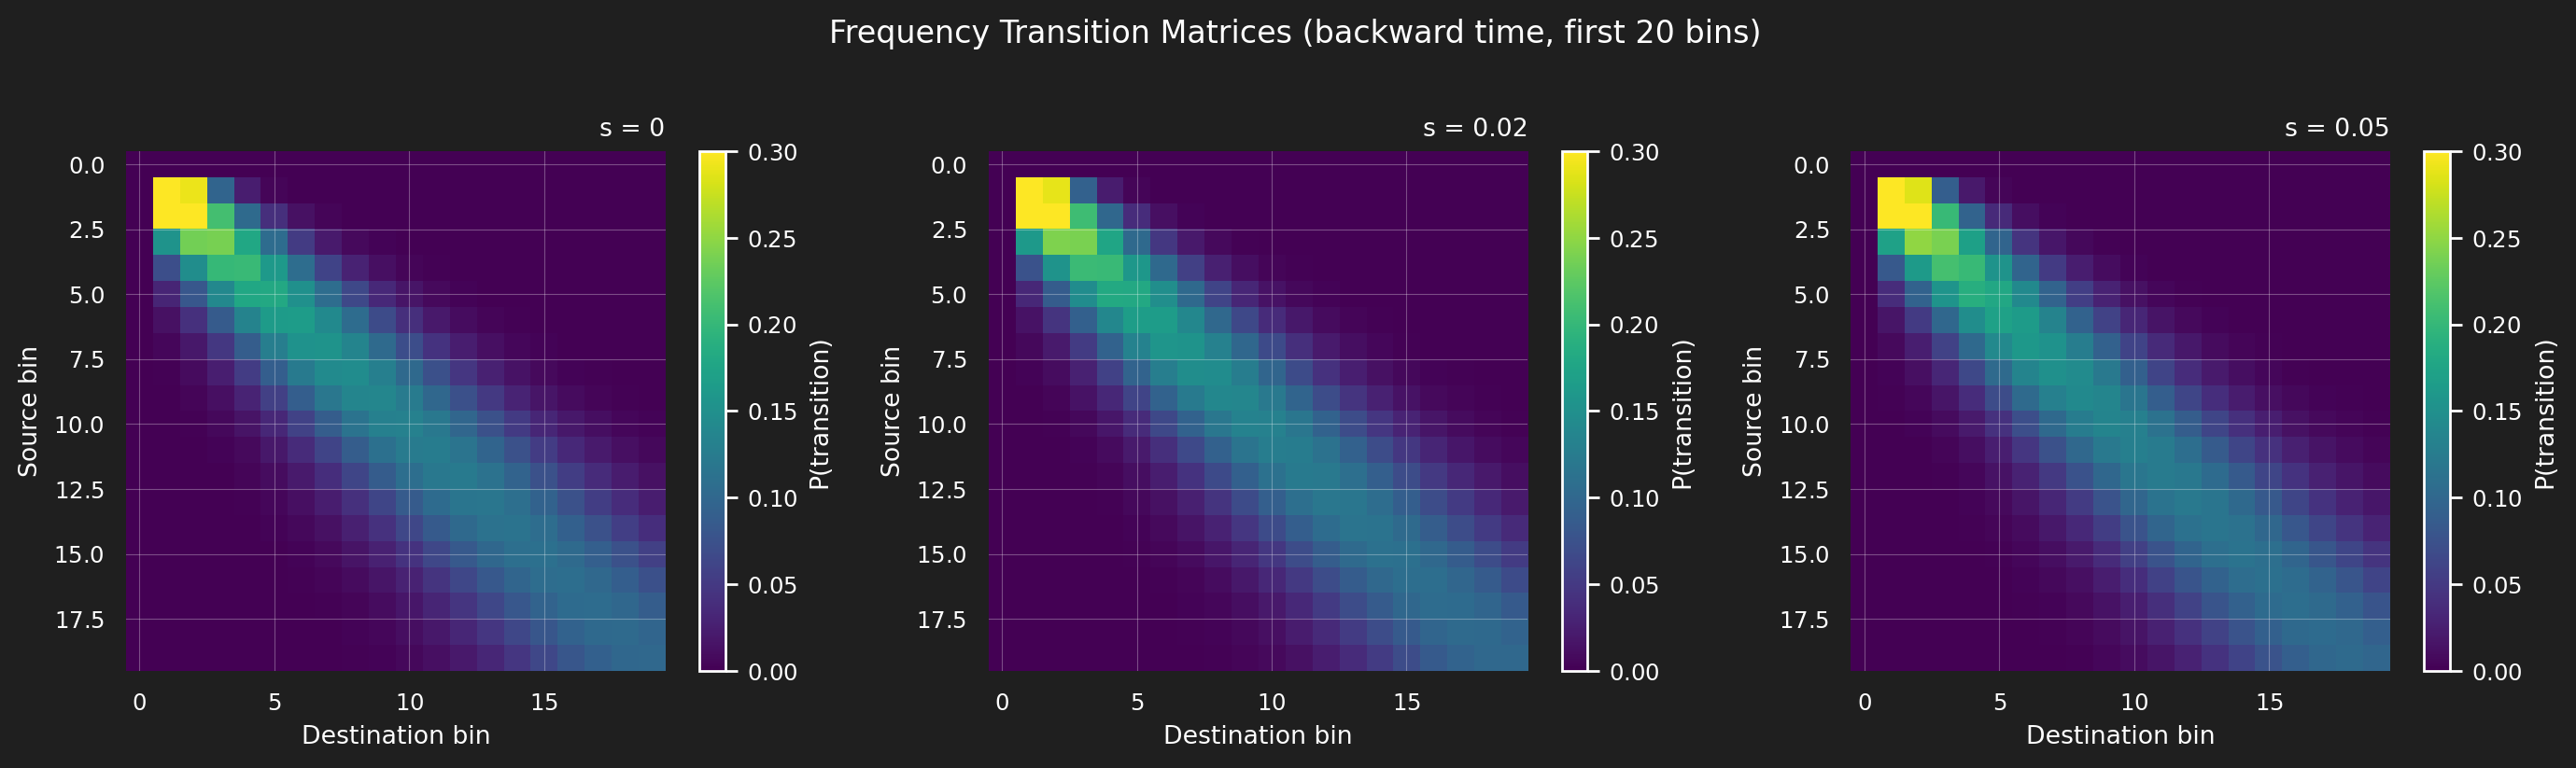

In [2]:
def kahan_sum(x: np.ndarray) -> float:
    """
    Numerically stable summation using Kahan algorithm.
    
    Parameters
    ----------
    x : np.ndarray
        Array to sum
    
    Returns
    -------
    float
        Sum of elements
    """
    x = np.sort(x)  # Sort for better numerical stability
    s = x[0]
    c = 0.0
    for i in range(1, len(x)):
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def compute_transition_matrix(
    pop_size: int,
    bins: np.ndarray,
    sel_coef: float,
    include_zero: bool = False
) -> np.ndarray:
    """
    Compute frequency transition matrix for Wright-Fisher with selection.
    
    Parameters
    ----------
    pop_size : int
        Population size (2N for diploids)
    bins : np.ndarray
        Array of frequency bin values (counts, not frequencies)
    sel_coef : float
        Selection coefficient
    include_zero : bool
        If True, allow transitions to zero frequency
    
    Returns
    -------
    np.ndarray
        Transition matrix M[i,j] = P(bin i -> bin j)
    """
    n_bins = len(bins)
    M = np.zeros((n_bins, n_bins), dtype=np.float64)
    
    # Flip sign of s for backward time
    s = -sel_coef
    
    for i in range(n_bins):
        for j in range(n_bins):
            # No transition from zero frequency
            # Only allow transition to zero if specified
            if i == 0 or (j == 0 and not include_zero):
                M[i, j] = 0
                continue
            
            # Current frequency
            p = bins[i] / pop_size
            
            # Apply selection transformation
            p_tilde = p * (1 + s) / (p * (1 + s) + 1 - p)
            
            # Binomial transition probability
            M[i, j] = binom.pmf(bins[j], pop_size, p_tilde)
    
    # Normalize rows to sum to 1 (except first row)
    for i in range(1, n_bins):
        row_sum = kahan_sum(M[i, :])
        if row_sum > 0:
            M[i, :] /= row_sum
    
    return M


# Example: Visualize transition matrix
pop_size = 100
n_bins = pop_size
bins = np.arange(n_bins)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, s in enumerate([0, 0.02, 0.05]):
    M = compute_transition_matrix(pop_size, bins, s, include_zero=False)
    ax = axes[idx]
    im = ax.imshow(M[:20, :20], cmap='viridis', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xlabel('Destination bin')
    ax.set_ylabel('Source bin')
    ax.set_title(f's = {s}')
    plt.colorbar(im, ax=ax, label='P(transition)')

fig.suptitle('Frequency Transition Matrices (backward time, first 20 bins)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Initial Probability Vector

The initial frequency distribution is based on the **Beta distribution** that arises from observing $d$ derived and $n-d$ ancestral alleles in a sample:

$$p \sim \text{Beta}(d, n-d)$$

We discretize this into our frequency bins.

0.9999999999999999


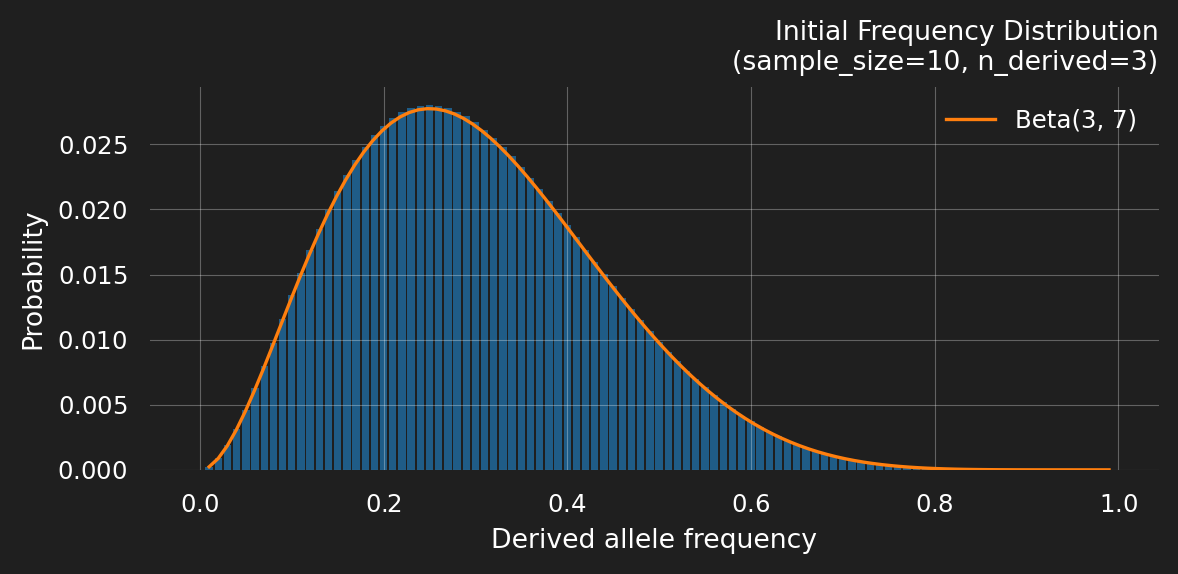

In [3]:
def compute_initial_probability_vector(
    pop_size: int,
    bins: np.ndarray,
    n_derived: int,
    sample_size: int
) -> np.ndarray:
    """
    Compute initial probability vector for frequency bins.
    
    Based on Beta(n_derived, sample_size - n_derived) prior.
    
    Parameters
    ----------
    pop_size : int
        Population size
    bins : np.ndarray
        Frequency bin values
    n_derived : int
        Number of derived alleles in sample
    sample_size : int
        Total sample size
    
    Returns
    -------
    np.ndarray
        Initial probability vector
    """
    n_bins = len(bins)
    ipv = np.zeros(n_bins)
    
    n_ancestral = sample_size - n_derived
    
    for i in range(n_bins):
        if bins[i] == 0:
            ipv[i] = 0  # Zero frequency has zero prior
        else:
            freq = bins[i] / pop_size
            ipv[i] = beta.pdf(freq, n_derived, n_ancestral)
    
    # Normalize
    ipv_sum = kahan_sum(ipv)
    if ipv_sum > 0:
        ipv /= ipv_sum
    
    return ipv


# Example
sample_size = 10
n_derived = 3
pop_size = 500
bins = np.arange(pop_size)

ipv = compute_initial_probability_vector(pop_size, bins, n_derived, sample_size)

print(ipv.sum())
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(bins / pop_size, ipv, width=0.008, alpha=0.7, color='C0')
ax.set_xlabel('Derived allele frequency')
ax.set_ylabel('Probability')
ax.set_title(f'Initial Frequency Distribution\n(sample_size={sample_size}, n_derived={n_derived})')

# Overlay Beta distribution
x = np.linspace(0.01, 0.99, 100)
y = beta.pdf(x, n_derived, sample_size - n_derived)
y = y / y.sum() * ipv.sum() #* len(bins)  # Scale to match histogram
ax.plot(x, y, color='C1',label=f'Beta({n_derived}, {sample_size - n_derived})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
indexer = StateIndexer(
    'freq',
    'is_ipv',
    lineage = [
        Property('is_derived', max_value=n_derived),
        Property('n_descendants', max_value=sample_size),        
    ],
)

# state [...tons..., freq]
# edge coeff
#  freq edge [freq_idx, 0, 0]
#  coal_edge [0, coal_rate, 0]
#  ipv edge [to_freq_idx, 0, 1]

# params [sel_coef, pop_size]


[INFO] phasic.graph_cache: Cleared 0 cached graphs


In [44]:
from phasic import (
    Graph, with_ipv, StateIndexer, Property, set_log_level, 
    clear_model_cache, clear_jax_cache, cache_info,
    print_model_cache_info, print_jax_cache_info
)
import numpy as np
from scipy.stats import binom, betabinom, beta
from scipy.special import comb
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')


def kahan_sum(x: np.ndarray) -> float:
    """
    Numerically stable summation using Kahan algorithm.
    
    Parameters
    ----------
    x : np.ndarray
        Array to sum
    
    Returns
    -------
    float
        Sum of elements
    """
    x = np.sort(x)  # Sort for better numerical stability
    s = x[0]
    c = 0.0
    for i in range(1, len(x)):
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def selection_graph(state, N=None, bin_size=None, sel_coef=None, indexer=None):

    transitions = []
    
    freqs = np.arange(0, N, bin_size) / N
    assert not (freqs.size - 2) % bin_size

    # lineage counts
    n_lineages = state[indexer.lineage.indices()].sum()
    n_derived = state[indexer.lineage.p2i(is_derived=1)].sum()
    if n_lineages <= 1:
        return []  # absorbing
       
    f_idx = state[indexer.freq]
    
    # Skip if at zero frequency with multiple derived lineages. ?????????????????
    if f_idx == 0 and n_derived > 1:
        return transitions
    
    # frequency
    for child_f_idx in range(n_freqbins):
    # for child_f_idx in sorted(range(n_freqbins), key=lambda x: abs(x-f_idx)):
        if child_f_idx == f_idx:
            continue
        
        # no transition to zero freq when more than one derived remain. # THIS SHOULD NOT BE NEEDED
        if child_f_idx == 0 and n_derived > 1:
            continue
        
        # no transition between non-zero bins if no derived remain. ????????
        if child_f_idx > 0 and n_derived == 0:
            continue
        
        # get transition rate
        if n_derived > 1 and child_f_idx == 0:
            rate = 0
        else:
            p = freqs[f_idx]
            s = -sel_coef
            p_tilde = p * (1 + s) / (p * (1 + s) + 1 - p)
            rate = binom.pmf(child_f_idx * bin_size, N, p_tilde)

            rate *= N  # Scale to match coalescent time scale
        
        if rate < 1e-30:
            break
        
        child_state = state.copy()
        child_state[indexer.freq] = child_f_idx
        
        transitions.append([child_state, rate])
        
    # coalescence
    for i, j in all_pairs(indexer.lineage):

        props_i = indexer.index_to_props(i)
        props_j = indexer.index_to_props(j)

        # Can't coalesce ancestral and derived unless freq is zero
        if props_i.lineage.is_derived != props_j.lineage.is_derived and f_idx != 0:
            continue
        
        # Calculate coalescence rate
        if i == j:
            if state[i] < 2:
                continue
            coal_rate = state[i] * (state[i] - 1) / 2 / N
        else:
            if state[i] < 1 or state[j] < 1:
                continue
            coal_rate = state[i] * state[j] / N
        
        # Scale by effective population fraction
        if n_derived > 1:
            if props_i.lineage.is_derived == 1:
                # Both derived - scale by derived frequency
                freq = f_idx * bin_size / N
            else:
                # Both ancestral - scale by ancestral frequency
                freq = (N - f_idx * bin_size) / N
        else:
            # Only one derived lineage - can coalesce freely
            freq = 1.0
        
        if freq <= 0:
            continue
        
        rate = coal_rate / freq
        
        # Create child state
        child_state = state.copy()
        child_state[i] -= 1
        child_state[j] -= 1
        
        # Determine resulting lineage type
        if props_i.lineage.is_derived and props_j.lineage.is_derived:
            # Both derived -> derived
            k = indexer.lineage.props_to_index(
                n_descendants=props_i.lineage.n_descendants + props_j.lineage.n_descendants,
                is_derived=1
            )
        else:
            # One or both ancestral -> ancestral
            k = indexer.lineage.props_to_index(
                n_descendants=props_i.lineage.n_descendants + props_j.lineage.n_descendants,
                is_derived=0
            )
        child_state[k] += 1
        
        transitions.append([child_state, rate])
        
    return transitions


from phasic.config import configure, get_available_options

# Check if MPFR is available
print(get_available_options()['mpfr'])  # True

# # Force high precision
# configure(force_high_precision=True)

# # Custom precision (256 bits ≈ 77 decimal digits)
# configure(mpfr_precision_bits=256)

# Lower threshold (more conservative)
configure(condition_threshold=1e12)

# # Disable condition warnings
# configure(enable_condition_warnings=False)

clear_model_cache()
clear_jax_cache()
set_log_level('DEBUG')

sample_size = 4
n_derived = 2
sel_coef = 0.0
N = 10
bin_size = 1

indexer = StateIndexer(
    'freq',
    lineage = [
        Property('is_derived', max_value=n_derived),
        Property('n_descendants', max_value=sample_size),        
    ],
)

n_freqbins = int(N / bin_size)
ipv_rates = np.zeros(n_freqbins)
n_ancestral = sample_size - n_derived
for i in range(n_freqbins):
    if i == 0:
        ipv_rates[i] = 0  # Zero frequency has zero prior
    else:
        freq = i * bin_size / N
        ipv_rates[i] = beta.pdf(freq, n_derived, n_ancestral)
# normalize to 1
ipv_sum = kahan_sum(ipv_rates)
if ipv_sum > 0:
    ipv_rates /= ipv_sum
ipv = []
for freq_bin in range(n_freqbins):
    if ipv_rates[freq_bin] < 1e-30:
        continue        
    initial_state = np.zeros(indexer.state_length, dtype=int)
    initial_state[indexer.p2i(n_descendants=1, is_derived=0)] = sample_size - n_derived
    initial_state[indexer.p2i(n_descendants=1, is_derived=1)] = n_derived
    initial_state[indexer.freq] = freq_bin
    ipv.append([initial_state, ipv_rates[freq_bin]])

graph = Graph(selection_graph, 
              ipv=ipv,
            cache=False, 
            #  hierarchical=True, 
              N=N, bin_size=bin_size, sel_coef=sel_coef, indexer=indexer)

#graph.vertices_length(), 
graph.expectation()

[DEBUG] phasic.graph_cache: GraphCache initialized: /Users/kmt/.phasic_cache/graphs
[INFO] phasic.graph_cache: Cleared 0 cached graphs


True


[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[INFO] phasic.c: Computing MPFR graph with 128-bit precision
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results


17.410487031402155

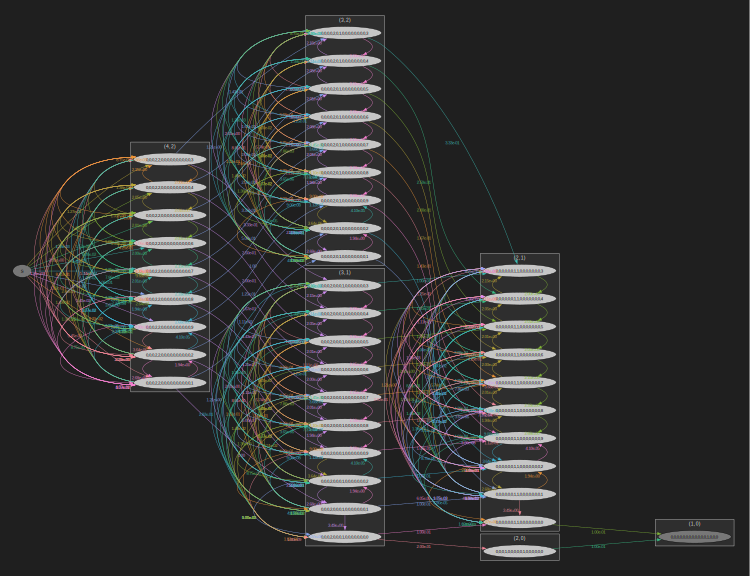

In [21]:
def by_nr_lin(state):
    return state[indexer.lineage.indices()].sum().item()

def by_anc_der(state):
    return (state[indexer.lineage.indices()].sum().item(),
            state[indexer.lineage.p2i(is_derived=1)].sum().item())

def by_freqbin(state):
    return state[indexer.freq].item()

graph.plot(max_nodes=350, 
           size=(15, 8), 
            # by_state=by_nr_lin, ranksep=8, nodesep=0.6,
           by_state=by_anc_der, ranksep=4, nodesep=0.6,
        #    by_state=by_freqbin, ranksep=1, nodesep=0.1,
        #    fontsize=25
           )

[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-pr

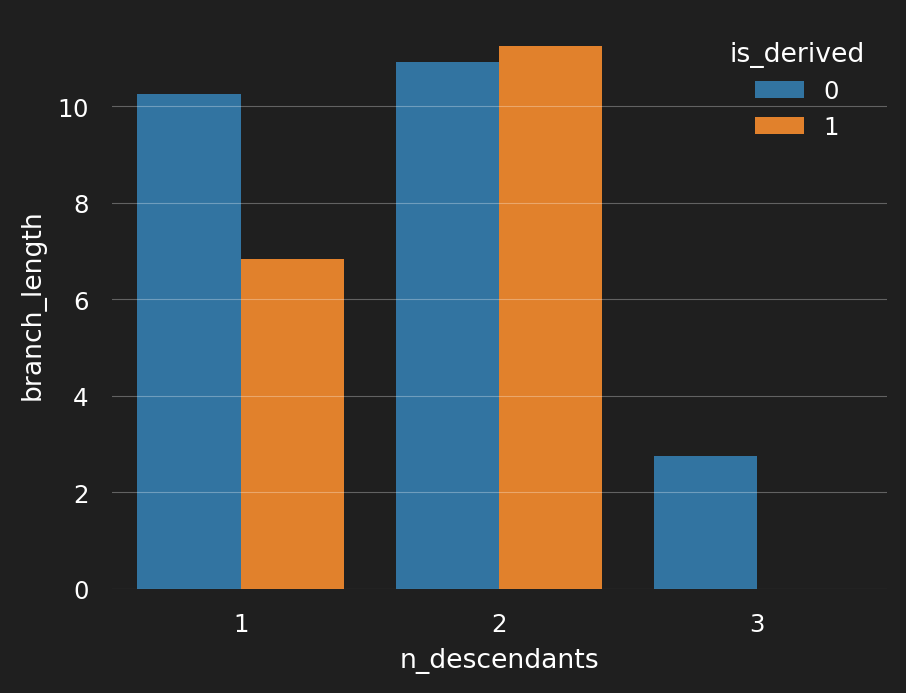

In [29]:
import pandas as pd

reward_matrix = graph.states().T
tons = range(1, sample_size)
rewards = [reward_matrix[indexer.lineage.p2i(n_descendants=x, is_derived=1)] for x in tons]
der_tons_branch_len = [graph.expectation(r) for r in rewards]
rewards = [reward_matrix[indexer.lineage.p2i(n_descendants=x, is_derived=0)] for x in tons]
anc_tons_branch_len = [graph.expectation(r) for r in rewards]

records = [(t, b, 1) for t, b in zip(tons, der_tons_branch_len)] + \
          [(t, b, 0) for t, b in zip(tons, anc_tons_branch_len)]

plot_df = pd.DataFrame().from_records(
    records, columns=['n_descendants', 'branch_length', 'is_derived']
)

sns.barplot(plot_df, x="n_descendants", y="branch_length", hue="is_derived", errorbar=None)
plt.show()

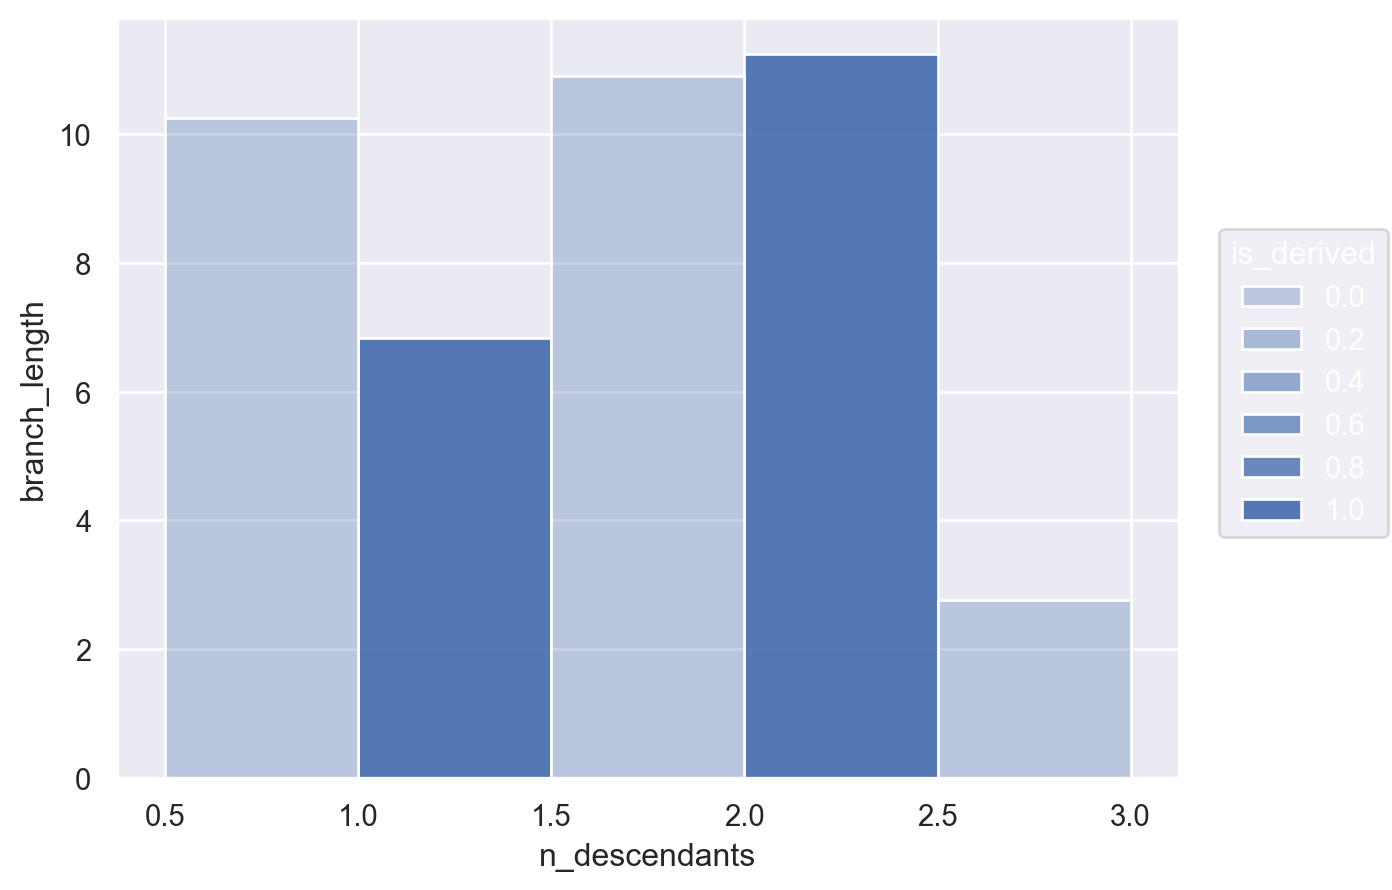

In [35]:
import seaborn.objects as so

(
    so.Plot(plot_df, x="n_descendants", y="branch_length", alpha="is_derived")
#    .facet("is_derived")
    # .add(so.Bars(), so.Stack())
    .add(so.Bars(), so.Dodge())
)

[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results
[INFO] phasic.c: Using MPFR for moment computation (condition 1.35e+16 > threshold 1.00e+12)
[DEBUG] phasic.c: MPFR computation completed successfully with 128-bit precision
[INFO] phasic.c: MPFR computation successful - returning high-precision results


<Figure size 500x370 with 0 Axes>

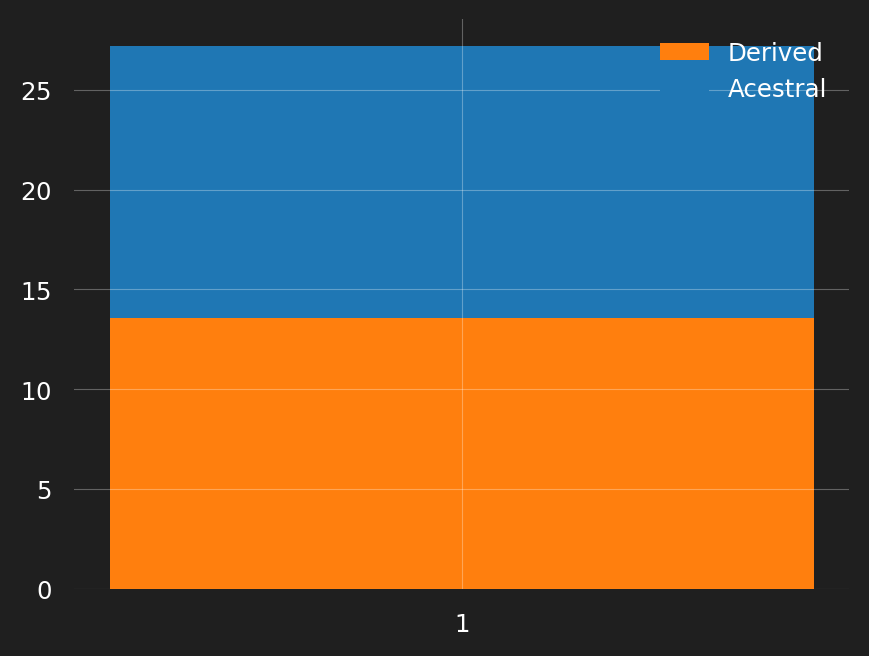

In [16]:
import matplotlib.pyplot as plt
import numpy as np

reward_matrix = graph.states().T
tons = range(1, sample_size)
rewards = [reward_matrix[indexer.lineage.p2i(n_descendants=x, is_derived=1)] for x in tons]
der_tons_branch_len = [graph.expectation(r) for r in rewards]
rewards = [reward_matrix[indexer.lineage.p2i(n_descendants=x, is_derived=0)] for x in tons]
anc_tons_branch_len = [graph.expectation(r) for r in rewards]

data = [
    ("Derived", der_tons_branch_len, 'C1'),
    ("Acestral", anc_tons_branch_len, 'C0'),
]
width = 0.5
fig, ax = plt.subplots()
bottom = np.zeros(len(tons))
x = list(map(str, tons))
for boolean, y, color in data:
    p = ax.bar(x, y, width, label=boolean, bottom=bottom, color=color)
    bottom += y
ax.legend(loc="upper right")
plt.show()

In [ ]:
# Build that plot for selection coefficients s = 0, 0.01, 0.05, 0.1 and compare the SFS shapes.

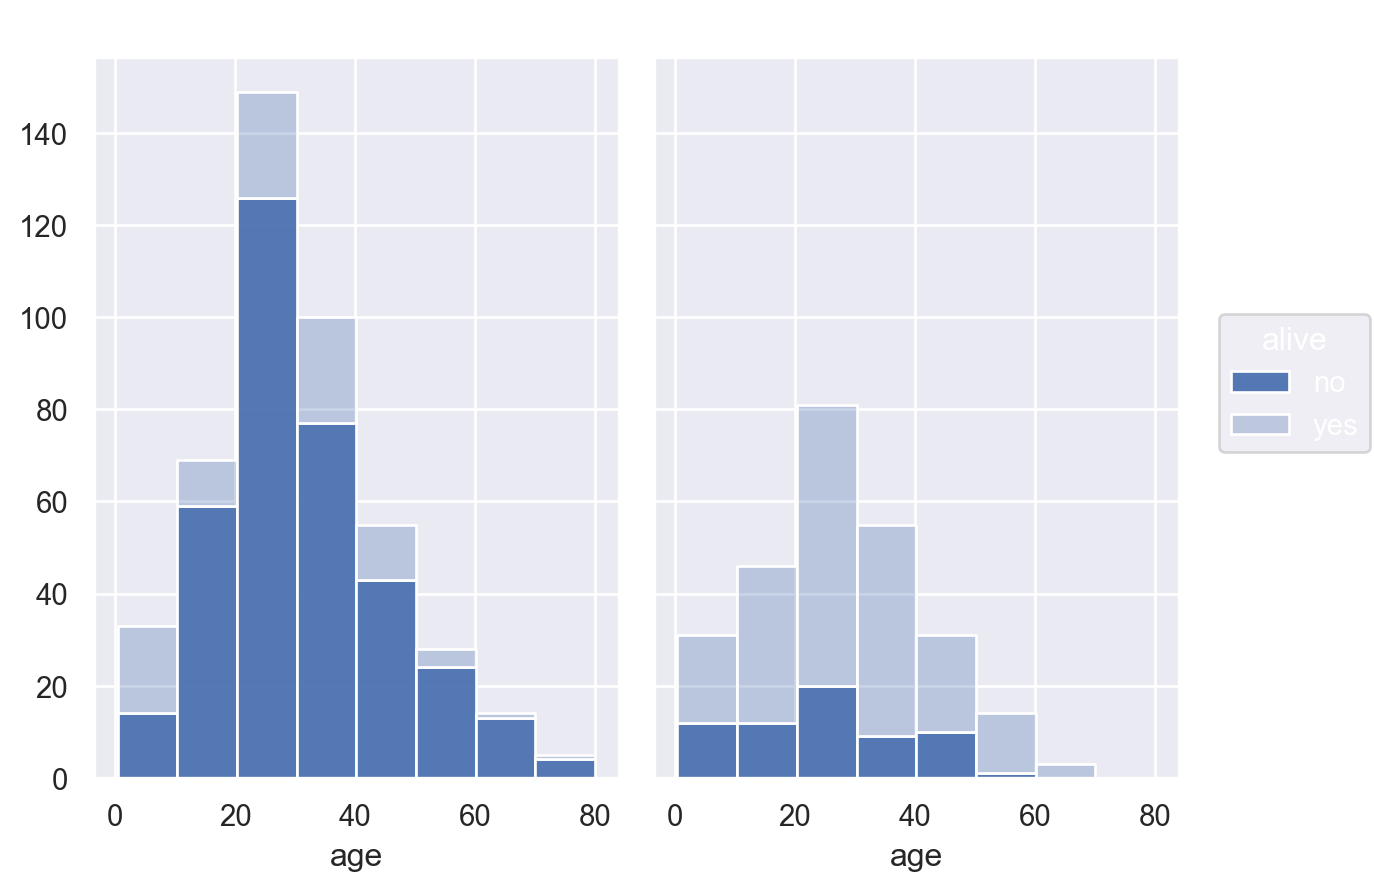

In [90]:
import seaborn.objects as so

titanic = sns.load_dataset("titanic")
(
    so.Plot(titanic, x="age", alpha="alive")
    .facet("sex")
    .add(so.Bars(), so.Hist(binwidth=10), so.Stack())
)

In [19]:
reward_matrix[idx]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,

In [8]:
x = 1
graph.states().T[:indexer.lineage.p2i(n_descendants=x)].T

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:

with set_log_level('INFO'):
    graph.compute_trace()
graph.vertices_length()

In [26]:
clear_model_cache()  

  Removed 2 file(s), preserved directory structure


In [27]:
print_model_cache_info()

Path: /Users/kmt/.phasic_cache
Cached compilations: 0
Total size: 0.0 MB


In [28]:
print_jax_cache_info()

Cache directory: /Users/kmt/.jax_cache
Cached compilations: 0
Total size: 0.0 MB


In [29]:
graph = Graph(selection_graph, 
              cache=True, 
            #   hierarchical=True, 
              N=pop_size, indexer=indexer)
graph.vertices_length()


23

In [21]:
with set_log_level('INFO'):
    graph.compute_trace()
graph.vertices_length()

[INFO] phasic.trace_elimination: Trace recording complete: 12 vertices, 1278 operations, phase 2, param_length=1, reward_length=0


12

In [22]:
graph.parameterized(), graph.param_length()

(False, 1)

In [23]:
graph.expectation()

100.318519188668

In [ ]:
def construct_coalescent_selection_graph(
    sample_size: int,
    n_derived: int,
    pop_size: int,
    sel_coef: float = 0.0,
    N: float = 1.0  # Scaled population size
) -> Graph:
    """
    Construct a phase-type graph for the coalescent with selection.
    
    This builds the state space and transition rates for a coalescent
    process where a derived allele is under selection.
    
    Parameters
    ----------
    sample_size : int
        Total number of sampled sequences
    n_derived : int
        Number of sequences carrying the derived allele
    pop_size : int
        Effective population size (determines number of frequency bins)
    sel_coef : float
        Selection coefficient (positive = beneficial)
    N : float
        Scaled population size for coalescent (default 1)
    
    Returns
    -------
    Graph
        Phasic graph representing the phase-type distribution
    """
    # State vector structure:
    # [ancestral_0desc, ..., ancestral_ndesc, derived_0desc, ..., derived_ndesc, freq_bin]
    state_length = (sample_size + 1) * 2 + 1
    freq_bin_index = state_length - 1
    
    # Frequency bins
    n_freqbins = pop_size
    bins = np.arange(n_freqbins)
    
    # Compute transition matrices
    freq_trans = compute_transition_matrix(pop_size, bins, sel_coef, include_zero=False)
    freq_trans_incl_zero = compute_transition_matrix(pop_size, bins, sel_coef, include_zero=True)
    
    # Initial probability vector for frequencies
    ipv_rates = compute_initial_probability_vector(pop_size, bins, n_derived, sample_size)
    
    # Store states and transitions for graph construction
    states = []  # List of state vectors
    state_to_idx = {}  # Map state tuple to index
    transitions = []  # List of (from_idx, to_idx, rate)
    initial_probs = []  # Initial state probabilities
    
    def state_to_tuple(state):
        return tuple(state)
    
    def find_or_create_state(state):
        key = state_to_tuple(state)
        if key not in state_to_idx:
            idx = len(states)
            state_to_idx[key] = idx
            states.append(state.copy())
        return state_to_idx[key]
    
    # Create initial states for each frequency bin
    for freq_bin in range(n_freqbins):
        if ipv_rates[freq_bin] < 1e-30:
            continue
            
        initial_state = np.zeros(state_length, dtype=int)
        # Ancestral singletons
        initial_state[props_to_index(sample_size, 1, 0)] = sample_size - n_derived
        # Derived singletons
        initial_state[props_to_index(sample_size, 1, 1)] = n_derived
        # Frequency bin
        initial_state[freq_bin_index] = freq_bin
        
        idx = find_or_create_state(initial_state)
        initial_probs.append((idx, ipv_rates[freq_bin]))
    
    # Process states to build transition graph
    processed = set()
    queue = list(range(len(states)))
    
    while queue:
        state_idx = queue.pop(0)
        if state_idx in processed:
            continue
        processed.add(state_idx)
        
        state = states[state_idx]
        
        # Count lineages
        n_lineages = sum(state[:-1])  # Exclude frequency bin
        if n_lineages <= 1:
            # Absorbing state (MRCA reached)
            continue
        
        # Count derived lineages
        n_derived_lineages = 0
        for i in range(state_length - 1):
            props = index_to_props(sample_size, i)
            if props.is_derived:
                n_derived_lineages += state[i]
        
        cur_freq_bin = state[freq_bin_index]
        
        # Skip if at zero frequency with multiple derived lineages
        if cur_freq_bin == 0 and n_derived_lineages > 1:
            continue
        
        # === Frequency transitions ===
        for next_freq_bin in range(n_freqbins):
            if next_freq_bin == cur_freq_bin:
                continue
            
            # Don't transition to zero unless only one derived remains
            if next_freq_bin == 0 and n_derived_lineages > 1:
                continue
            
            # Don't transition between non-zero bins if no derived remain
            if next_freq_bin > 0 and n_derived_lineages == 0:
                continue
            
            # Get transition rate
            if n_derived_lineages > 1:
                rate = freq_trans[cur_freq_bin, next_freq_bin]
            else:
                rate = freq_trans_incl_zero[cur_freq_bin, next_freq_bin]
            
            rate *= pop_size  # Scale to match coalescent time scale
            
            if rate < 1e-30:
                continue
            
            child_state = state.copy()
            child_state[freq_bin_index] = next_freq_bin
            
            child_idx = find_or_create_state(child_state)
            transitions.append((state_idx, child_idx, rate))
            
            if child_idx not in processed:
                queue.append(child_idx)
        
        # === Coalescence events ===
        for i in range(state_length - 1):
            props_i = index_to_props(sample_size, i)
            
            for j in range(i, state_length - 1):
                props_j = index_to_props(sample_size, j)
                
                # Can't coalesce ancestral and derived unless freq is zero
                if props_i.is_derived != props_j.is_derived and cur_freq_bin != 0:
                    continue
                
                # Calculate coalescence rate
                if i == j:
                    if state[i] < 2:
                        continue
                    coal_rate = state[i] * (state[i] - 1) / 2 / N
                else:
                    if state[i] < 1 or state[j] < 1:
                        continue
                    coal_rate = state[i] * state[j] / N
                
                # Scale by effective population fraction
                if n_derived_lineages > 1:
                    if props_i.is_derived == 1:
                        # Both derived - scale by derived frequency
                        freq = bins[cur_freq_bin] / pop_size
                    else:
                        # Both ancestral - scale by ancestral frequency
                        freq = (pop_size - bins[cur_freq_bin]) / pop_size
                else:
                    # Only one derived lineage - can coalesce freely
                    freq = 1.0
                
                if freq <= 0:
                    continue
                
                rate = coal_rate / freq
                
                # Create child state
                child_state = state.copy()
                child_state[i] -= 1
                child_state[j] -= 1
                
                # Determine resulting lineage type
                if props_i.is_derived and props_j.is_derived:
                    # Both derived -> derived
                    k = props_to_index(
                        sample_size,
                        props_i.n_descendants + props_j.n_descendants,
                        1
                    )
                else:
                    # One or both ancestral -> ancestral
                    k = props_to_index(
                        sample_size,
                        props_i.n_descendants + props_j.n_descendants,
                        0
                    )
                
                child_state[k] += 1
                
                child_idx = find_or_create_state(child_state)
                transitions.append((state_idx, child_idx, rate))
                
                if child_idx not in processed:
                    queue.append(child_idx)
    
    # Build phasic Graph
    # Create callback that returns edges based on state index
    n_states = len(states)
    
    # Build adjacency list
    adj_list = {i: [] for i in range(n_states)}
    for from_idx, to_idx, rate in transitions:
        adj_list[from_idx].append((to_idx, rate))
    
    # Use phasic Graph callback-based construction
    def callback(state):
        state_idx = state[0]
        edges = []
        for to_idx, rate in adj_list.get(state_idx, []):
            edges.append((np.array([to_idx], dtype=np.int64), rate))
        return edges
    
    # Create graph with indexed states
    graph = Graph(
        callback,
        parameterized=False
    )
    
    # Add initial states
    for idx, prob in initial_probs:
        starting_vertex = graph.starting_vertex()
        vertex = graph.find_or_create_vertex(np.array([idx], dtype=np.int64))
        starting_vertex.add_edge(vertex, prob)
    
    # Trigger graph construction
    for state_idx in range(n_states):
        _ = graph.find_or_create_vertex(np.array([state_idx], dtype=np.int64))
    
    return graph, states, transitions, initial_probs

In [ ]:
graph = construct_coalescent_selection_graph(
    sample_size=4,
    n_derived=2,
    pop_size=100,
    sel_coef=0,
    N=1.0,
)
graph.plot()

NameError: name 'props_to_index' is not defined

## Alternative: Direct Matrix Construction

For simpler use cases, we can directly construct the sub-intensity matrix and initial probability vector without using phasic's graph builder.

In [37]:
def construct_coalescent_selection_matrix(
    sample_size: int,
    n_derived: int,
    pop_size: int,
    sel_coef: float = 0.0,
    N: float = 1.0
) -> Tuple[np.ndarray, np.ndarray, List[np.ndarray]]:
    """
    Construct sub-intensity matrix and IPV for coalescent with selection.
    
    Returns
    -------
    sim : np.ndarray
        Sub-intensity matrix
    ipv : np.ndarray
        Initial probability vector
    states : List[np.ndarray]
        List of state vectors
    """
    state_length = (sample_size + 1) * 2 + 1
    freq_bin_index = state_length - 1
    
    n_freqbins = pop_size
    bins = np.arange(n_freqbins)
    
    freq_trans = compute_transition_matrix(pop_size, bins, sel_coef, include_zero=False)
    freq_trans_incl_zero = compute_transition_matrix(pop_size, bins, sel_coef, include_zero=True)
    ipv_rates = compute_initial_probability_vector(pop_size, bins, n_derived, sample_size)
    
    # Build state space
    states = []
    state_to_idx = {}
    transitions = []
    initial_probs = []
    
    def state_key(state):
        return tuple(state)
    
    def get_or_create_state(state):
        key = state_key(state)
        if key not in state_to_idx:
            idx = len(states)
            state_to_idx[key] = idx
            states.append(state.copy())
        return state_to_idx[key]
    
    # Initial states
    for freq_bin in range(n_freqbins):
        if ipv_rates[freq_bin] < 1e-30:
            continue
        
        initial_state = np.zeros(state_length, dtype=int)
        initial_state[props_to_index(sample_size, 1, 0)] = sample_size - n_derived
        initial_state[props_to_index(sample_size, 1, 1)] = n_derived
        initial_state[freq_bin_index] = freq_bin
        
        idx = get_or_create_state(initial_state)
        initial_probs.append((idx, ipv_rates[freq_bin]))
    
    # Build transitions
    processed = set()
    queue = list(range(len(states)))
    
    while queue:
        state_idx = queue.pop(0)
        if state_idx in processed:
            continue
        processed.add(state_idx)
        
        state = states[state_idx]
        n_lineages = sum(state[:-1])
        
        if n_lineages <= 1:
            continue
        
        n_derived_lineages = sum(
            state[i] for i in range(state_length - 1)
            if index_to_props(sample_size, i).is_derived
        )
        
        cur_freq_bin = state[freq_bin_index]
        
        if cur_freq_bin == 0 and n_derived_lineages > 1:
            continue
        
        # Frequency transitions
        for next_freq_bin in range(n_freqbins):
            if next_freq_bin == cur_freq_bin:
                continue
            if next_freq_bin == 0 and n_derived_lineages > 1:
                continue
            if next_freq_bin > 0 and n_derived_lineages == 0:
                continue
            
            if n_derived_lineages > 1:
                rate = freq_trans[cur_freq_bin, next_freq_bin]
            else:
                rate = freq_trans_incl_zero[cur_freq_bin, next_freq_bin]
            
            rate *= pop_size
            
            if rate < 1e-30:
                continue
            
            child_state = state.copy()
            child_state[freq_bin_index] = next_freq_bin
            
            child_idx = get_or_create_state(child_state)
            transitions.append((state_idx, child_idx, rate))
            
            if child_idx not in processed:
                queue.append(child_idx)
        
        # Coalescence events
        for i in range(state_length - 1):
            props_i = index_to_props(sample_size, i)
            
            for j in range(i, state_length - 1):
                props_j = index_to_props(sample_size, j)
                
                if props_i.is_derived != props_j.is_derived and cur_freq_bin != 0:
                    continue
                
                if i == j:
                    if state[i] < 2:
                        continue
                    coal_rate = state[i] * (state[i] - 1) / 2 / N
                else:
                    if state[i] < 1 or state[j] < 1:
                        continue
                    coal_rate = state[i] * state[j] / N
                
                if n_derived_lineages > 1:
                    if props_i.is_derived:
                        freq = bins[cur_freq_bin] / pop_size
                    else:
                        freq = (pop_size - bins[cur_freq_bin]) / pop_size
                else:
                    freq = 1.0
                
                if freq <= 0:
                    continue
                
                rate = coal_rate / freq
                
                child_state = state.copy()
                child_state[i] -= 1
                child_state[j] -= 1
                
                if props_i.is_derived and props_j.is_derived:
                    k = props_to_index(
                        sample_size,
                        props_i.n_descendants + props_j.n_descendants,
                        1
                    )
                else:
                    k = props_to_index(
                        sample_size,
                        props_i.n_descendants + props_j.n_descendants,
                        0
                    )
                
                child_state[k] += 1
                
                child_idx = get_or_create_state(child_state)
                transitions.append((state_idx, child_idx, rate))
                
                if child_idx not in processed:
                    queue.append(child_idx)
    
    # Build matrix
    n_states = len(states)
    sim = np.zeros((n_states, n_states))
    ipv = np.zeros(n_states)
    
    for from_idx, to_idx, rate in transitions:
        sim[from_idx, to_idx] += rate
    
    # Set diagonal (negative sum of off-diagonal)
    for i in range(n_states):
        sim[i, i] = -np.sum(sim[i, :]) - 1.0  # Add exit rate of 1.0 for absorbing
    
    # Initial probability vector
    for idx, prob in initial_probs:
        ipv[idx] = prob
    
    return sim, ipv, states

# Validation and Examples

## 4.1 Sanity Checks

Let's verify our implementation with some known results.

In [ ]:
print("Sanity Check 1: Single ancestral, single derived (n=2, d=1)")
print("=" * 60)
print("\nExpected: E[T] ≈ 2 (1 for derived coalescence + 1 for final)")
print("")

# With large population size, should converge to theoretical value
for pop_size in [50, 100, 500, 1000]:
    sim, ipv, states = construct_coalescent_selection_matrix(
        sample_size=2,
        n_derived=1,
        pop_size=pop_size,
        sel_coef=0.0
    )
    
    # Compute expected time using phase-type formula
    # E[T] = -alpha * S^{-1} * 1
    try:
        S_inv = np.linalg.inv(sim)
        ones = np.ones(len(ipv))
        expected_time = -np.dot(ipv, np.dot(S_inv, ones))
        print(f"  pop_size={pop_size:4d}: E[T] = {expected_time:.4f}")
    except np.linalg.LinAlgError:
        print(f"  pop_size={pop_size:4d}: Matrix singular")

Sanity Check 1: Single ancestral, single derived (n=2, d=1)

Expected: E[T] ≈ 2 (1 for derived coalescence + 1 for final)



NameError: name 'construct_coalescent_selection_matrix' is not defined

In [ ]:
print("\nSanity Check 2: Many ancestral, single derived (n=20, d=1)")
print("=" * 60)
print("\nExpected: E[T] ≈ 2 + 1/(n-1) = 2 + 1/9 ≈ 2.053")
print("(Tree height 2 + extra waiting time for single derived)")
print("")

for pop_size in [50, 100, 200]:
    sim, ipv, states = construct_coalescent_selection_matrix(
        sample_size=10,
        n_derived=1,
        pop_size=pop_size,
        sel_coef=0.0
    )
    
    try:
        S_inv = np.linalg.inv(sim)
        ones = np.ones(len(ipv))
        expected_time = -np.dot(ipv, np.dot(S_inv, ones))
        print(f"  pop_size={pop_size:3d}: E[T] = {expected_time:.4f} (n_states={len(states)})")
    except np.linalg.LinAlgError:
        print(f"  pop_size={pop_size:3d}: Matrix singular")


Sanity Check 2: Many ancestral, single derived (n=20, d=1)

Expected: E[T] ≈ 2 + 1/(n-1) = 2 + 1/9 ≈ 2.053
(Tree height 2 + extra waiting time for single derived)

  pop_size= 50: E[T] = 1.0000 (n_states=1541)
  pop_size=100: E[T] = 1.0000 (n_states=3041)
  pop_size=200: E[T] = 1.0000 (n_states=6041)


In [ ]:
print("\nSanity Check 3: Symmetry test (d derived vs n-d derived)")
print("=" * 60)
print("\nExpected: E[T] should be the same for d and n-d derived")
print("(Under neutrality, ancestral and derived are symmetric)")
print("")

sample_size = 4
pop_size = 100

for n_derived in [1, 2, 3]:
    sim1, ipv1, states1 = construct_coalescent_selection_matrix(
        sample_size=sample_size,
        n_derived=n_derived,
        pop_size=pop_size,
        sel_coef=0.0
    )
    
    sim2, ipv2, states2 = construct_coalescent_selection_matrix(
        sample_size=sample_size,
        n_derived=sample_size - n_derived,
        pop_size=pop_size,
        sel_coef=0.0
    )
    
    try:
        S_inv1 = np.linalg.inv(sim1)
        S_inv2 = np.linalg.inv(sim2)
        et1 = -np.dot(ipv1, np.dot(S_inv1, np.ones(len(ipv1))))
        et2 = -np.dot(ipv2, np.dot(S_inv2, np.ones(len(ipv2))))
        print(f"  d={n_derived}: E[T]={et1:.4f}  |  d={sample_size-n_derived}: E[T]={et2:.4f}  |  diff={abs(et1-et2):.6f}")
    except np.linalg.LinAlgError:
        print(f"  d={n_derived}: Matrix singular")


Sanity Check 3: Symmetry test (d derived vs n-d derived)

Expected: E[T] should be the same for d and n-d derived
(Under neutrality, ancestral and derived are symmetric)

  d=1: E[T]=1.0000  |  d=3: E[T]=1.0000  |  diff=0.000000
  d=2: E[T]=1.0000  |  d=2: E[T]=1.0000  |  diff=0.000000
  d=3: E[T]=1.0000  |  d=1: E[T]=1.0000  |  diff=0.000000


## 4.2 Effect of Selection on Tree Length

Selection affects the expected total tree length:
- **Positive selection** ($s > 0$): Beneficial alleles sweep faster, reducing tree length on the derived branch
- **Negative selection** ($s < 0$): Deleterious alleles are removed, increasing time to coalescence

Effect of Selection on Expected Coalescence Time
sample_size=4, n_derived=2, pop_size=100



Computing:   0%|          | 0/11 [00:00<?, ?it/s]

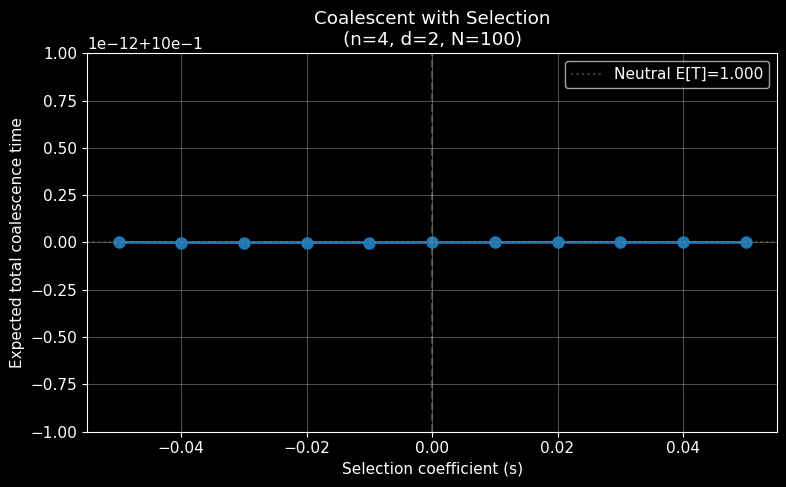

In [ ]:
# Compare expected times for different selection coefficients
sample_size = 4
n_derived = 2
pop_size = 100

selection_values = np.linspace(-0.05, 0.05, 11)
expected_times = []

print("Effect of Selection on Expected Coalescence Time")
print("=" * 50)
print(f"sample_size={sample_size}, n_derived={n_derived}, pop_size={pop_size}")
print("")

for s in tqdm(selection_values, desc="Computing"):
    sim, ipv, states = construct_coalescent_selection_matrix(
        sample_size=sample_size,
        n_derived=n_derived,
        pop_size=pop_size,
        sel_coef=s
    )
    
    try:
        S_inv = np.linalg.inv(sim)
        et = -np.dot(ipv, np.dot(S_inv, np.ones(len(ipv))))
        expected_times.append(et)
    except np.linalg.LinAlgError:
        expected_times.append(np.nan)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(selection_values, expected_times, 'o-', linewidth=2, markersize=8)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(expected_times[len(selection_values)//2], color='gray', linestyle=':', alpha=0.5, 
           label=f'Neutral E[T]={expected_times[len(selection_values)//2]:.3f}')
ax.set_xlabel('Selection coefficient (s)')
ax.set_ylabel('Expected total coalescence time')
ax.set_title(f'Coalescent with Selection\n(n={sample_size}, d={n_derived}, N={pop_size})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 State Space Visualization

Let's visualize the state space for a small example.

In [ ]:
def describe_state(state, sample_size):
    """Create a human-readable description of a state."""
    state_length = len(state)
    freq_bin_index = state_length - 1
    
    anc_desc = []
    der_desc = []
    
    for i in range(state_length - 1):
        if state[i] > 0:
            props = index_to_props(sample_size, i)
            desc = f"{state[i]}×{props.n_descendants}desc"
            if props.is_derived:
                der_desc.append(desc)
            else:
                anc_desc.append(desc)
    
    anc_str = ", ".join(anc_desc) if anc_desc else "none"
    der_str = ", ".join(der_desc) if der_desc else "none"
    
    return f"Anc:[{anc_str}] Der:[{der_str}] freq_bin={state[freq_bin_index]}"


# Build a small example
sample_size = 3
n_derived = 2
pop_size = 10

sim, ipv, states = construct_coalescent_selection_matrix(
    sample_size=sample_size,
    n_derived=n_derived,
    pop_size=pop_size,
    sel_coef=0.0
)

print(f"State Space for n={sample_size}, d={n_derived}, N={pop_size}")
print("=" * 70)
print(f"Number of states: {len(states)}")
print("")

# Show first 20 states
print("First 20 states:")
print("-" * 70)
for idx, state in enumerate(states[:20]):
    desc = describe_state(state, sample_size)
    ipv_val = ipv[idx] if idx < len(ipv) else 0
    print(f"  {idx:3d}: {desc}  [IPV={ipv_val:.4f}]")

if len(states) > 20:
    print(f"  ... ({len(states) - 20} more states)")

State Space for n=3, d=2, N=10
Number of states: 20

First 20 states:
----------------------------------------------------------------------
    0: Anc:[1×1desc] Der:[2×1desc] freq_bin=1  [IPV=0.0222]
    1: Anc:[1×1desc] Der:[2×1desc] freq_bin=2  [IPV=0.0444]
    2: Anc:[1×1desc] Der:[2×1desc] freq_bin=3  [IPV=0.0667]
    3: Anc:[1×1desc] Der:[2×1desc] freq_bin=4  [IPV=0.0889]
    4: Anc:[1×1desc] Der:[2×1desc] freq_bin=5  [IPV=0.1111]
    5: Anc:[1×1desc] Der:[2×1desc] freq_bin=6  [IPV=0.1333]
    6: Anc:[1×1desc] Der:[2×1desc] freq_bin=7  [IPV=0.1556]
    7: Anc:[1×1desc] Der:[2×1desc] freq_bin=8  [IPV=0.1778]
    8: Anc:[1×1desc] Der:[2×1desc] freq_bin=9  [IPV=0.2000]
    9: Anc:[1×1desc] Der:[1×2desc] freq_bin=1  [IPV=0.0000]
   10: Anc:[1×1desc] Der:[1×2desc] freq_bin=2  [IPV=0.0000]
   11: Anc:[1×1desc] Der:[1×2desc] freq_bin=3  [IPV=0.0000]
   12: Anc:[1×1desc] Der:[1×2desc] freq_bin=4  [IPV=0.0000]
   13: Anc:[1×1desc] Der:[1×2desc] freq_bin=5  [IPV=0.0000]
   14: Anc:[1×1desc

## 4.4 Using phasic Graph for PDF Computation

Now let's use the phasic library to compute the PDF of the coalescence time.

In [ ]:
# Build a phasic Graph from the matrix
sample_size = 3
n_derived = 1  
pop_size = 50

sim, ipv, states = construct_coalescent_selection_matrix(
    sample_size=sample_size,
    n_derived=n_derived,
    pop_size=pop_size,
    sel_coef=0.0
)

print(f"Built coalescent model: {len(states)} states")
print(f"Sub-intensity matrix shape: {sim.shape}")
print(f"Initial probability vector: {ipv[:10]}... (showing first 10)")

# Create phasic Graph from matrix
graph = Graph.from_matrices(ipv, sim)
print(f"\nCreated phasic Graph with {graph.vertices_length()} vertices")

Built coalescent model: 102 states
Sub-intensity matrix shape: (102, 102)
Initial probability vector: [0.04       0.03918367 0.03836735 0.03755102 0.03673469 0.03591837
 0.03510204 0.03428571 0.03346939 0.03265306]... (showing first 10)

Created phasic Graph with 104 vertices


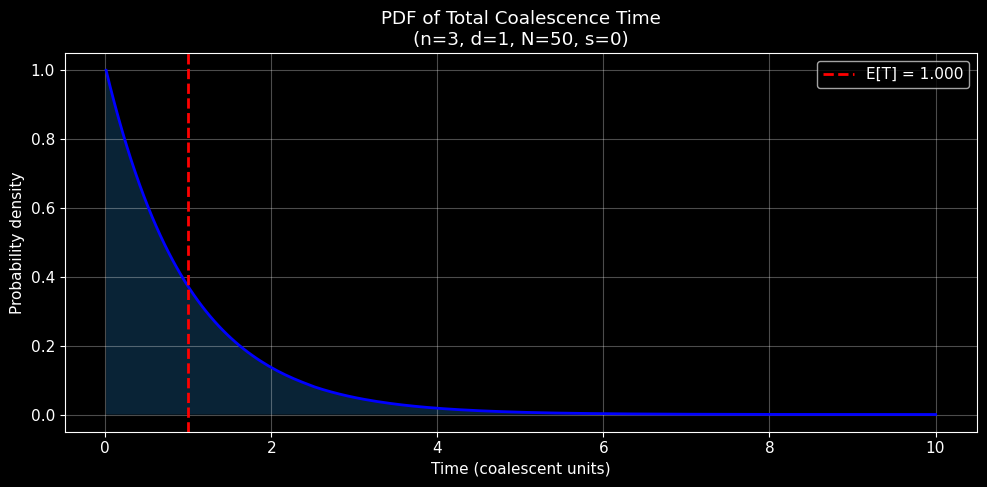

In [ ]:
# Compute PDF at various time points
times = np.linspace(0.01, 10, 200)

# Compute PDF values
pdf_values = graph.pdf(times, granularity=100)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, pdf_values, 'b-', linewidth=2)
ax.fill_between(times, pdf_values, alpha=0.3)
ax.set_xlabel('Time (coalescent units)')
ax.set_ylabel('Probability density')
ax.set_title(f'PDF of Total Coalescence Time\n(n={sample_size}, d={n_derived}, N={pop_size}, s=0)')
ax.grid(True, alpha=0.3)

# Add expected time
S_inv = np.linalg.inv(sim)
expected_time = -np.dot(ipv, np.dot(S_inv, np.ones(len(ipv))))
ax.axvline(expected_time, color='red', linestyle='--', linewidth=2, 
           label=f'E[T] = {expected_time:.3f}')
ax.legend()

plt.tight_layout()
plt.show()

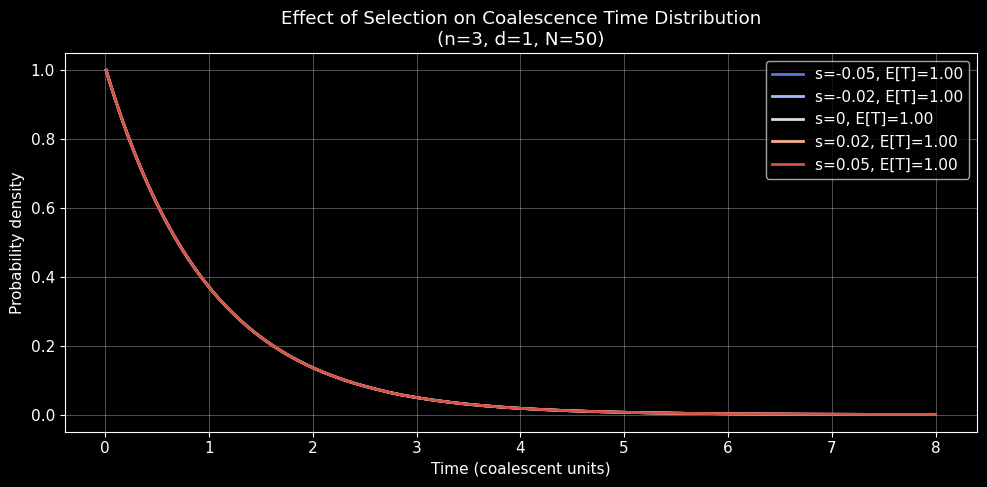

In [ ]:
# Compare PDFs for different selection strengths
fig, ax = plt.subplots(figsize=(10, 5))

selection_values = [-0.05, -0.02, 0, 0.02, 0.05]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(selection_values)))
times = np.linspace(0.01, 8, 200)

for s, c in zip(selection_values, colors):
    sim, ipv, states = construct_coalescent_selection_matrix(
        sample_size=sample_size,
        n_derived=n_derived,
        pop_size=pop_size,
        sel_coef=s
    )
    
    graph = Graph.from_matrices(ipv, sim)
    pdf_values = graph.pdf(times, granularity=100)
    
    # Compute expected time
    S_inv = np.linalg.inv(sim)
    et = -np.dot(ipv, np.dot(S_inv, np.ones(len(ipv))))
    
    ax.plot(times, pdf_values, color=c, linewidth=2, label=f's={s}, E[T]={et:.2f}')

ax.set_xlabel('Time (coalescent units)')
ax.set_ylabel('Probability density')
ax.set_title(f'Effect of Selection on Coalescence Time Distribution\n(n={sample_size}, d={n_derived}, N={pop_size})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Part 5: Summary

## Key Concepts

1. **State Space**: Each state tracks the number of ancestral and derived lineages by their descendant count, plus a frequency bin

2. **Transitions**:
   - **Frequency changes**: Wright-Fisher binomial sampling with selection
   - **Coalescence**: Lineages of the same type coalesce at rates inversely proportional to their population fraction

3. **Selection Effects**:
   - Positive selection ($s > 0$): Beneficial allele increases in frequency, faster coalescence among derived lineages
   - Negative selection ($s < 0$): Deleterious allele decreases, slower coalescence among derived

4. **Phase-Type Framework**: The coalescent with selection can be modeled as a continuous-time Markov chain, enabling efficient computation of:
   - Expected coalescence times
   - Full distribution of coalescence times
   - Moments of branch lengths

## References

- [Kimura (1962)](https://doi.org/10.1093/genetics/47.6.713) - On the probability of fixation of mutant genes in a population
- [Kaplan et al. (1988)](https://doi.org/10.1093/genetics/120.3.819) - The coalescent process in models with selection
- [Ewens (2004)](https://link.springer.com/book/10.1007/978-0-387-21822-9) - Mathematical Population Genetics
- [Røikjer et al. (2022)](https://doi.org/10.1007/s11222-022-10155-6) - Phase-type distribution algorithms